# Exploration strategies for DQN algorithm

In this assignment we are interested in exploration strategies that can be combined with Q-learning.
Q-learning is an off-policy algorithm, which means that the data for the algorithm can be collected by a different policy (called behavioural policy) that the one the algorithm learns.

Here we come across a classical trade-off in reinforcement learning, called exploration-exploitation trade-off. On the one hand, our behavioural policy should try out new state-action pairs to gain knowledge about their returns. On the other hand, when our estimate of returns is good enough, we would like to follow the state-action pairs with the highest estimated returns.

We will be operating on DQN [(Mnih 2014)](https://www.cs.toronto.edu/~vmnih/docs/dqn.pdf) algorithm and analyzing epsilon-greedy strategy, boltzmann and max-boltzmann strategy and combination of epsilon-greedy and boltzmann.
We evaluate performance of DQN variants on the Lunar Lander environment.

We provide an implementation of the DQN algorithm with random exploration strategy.
Your goal is to implement the exploration variants by overriding appropriate methods of the provided class.


## Grading

To obtain the points for the assignment You need to provide the implementation of exploration techniques AND report with plots and conclusions.
Measuring sensitivity means that You should at least examine one reasonably lower and one reasonably greater value of the considered hyperparameter (or the pair of hyperparameters).


1. Implement epsilon-greedy strategy and investigate hyperparameter sensitivity (1 point).
2. Implement epsilon-greedy strategy with epsilon annealing and investigate hyperparameter sensitivity (1 point).
3. Implement boltzmann strategy and investigate hyperparameter sensitivity (1 point).
4. Implement boltzmann strategy with temperature annealing and investigate hyperparameter sensitivity (1 point).
5. Implement max-boltzmann strategy and investigate hyperparameter sensitivity (1 point).
6. Implement max-boltzmann strategy with temperature annealing and investigate hyperparameter sensitivity (1 point).
7. Implement combination of epsilon-greedy with epsilon annealing and boltzmann strategy and investigate hyperparameter sensitivity (1 point)
8. (*) Bonus: propose another reasonable approach to combine epsilon-greedy with epsilon annealing strategy and boltzmann strategy and/or another reasonable strategy of temperature annealing for the boltzmann strategy (2 points).
9. Compare methods, present plots and conclusions in a clear manner (3 points).

You can obtain max 10 points, bonus points increase Your score, if You lose points in some other tasks.

Here we import necessary libraries.

In [1]:
# !apt-get install swig
# !pip install gymnasium[box2d]

In [2]:
import torch
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

Here we set hyperparameters of the training, set seeds for reproducibility and set weights initialization.
Although for debugging it might be useful to operate on a smaller number of training_steps, seeds etc., in the final evaluation DO NOT CHANGE these parameters.

In [3]:
class parse_args:
  def __init__(self):
    self.n_seeds = 6
    self.n_evaluate_episodes = 5
    self.n_training_steps = 100000
    self.buffer_size = 10000
    self.init_steps = 10000
    self.target_update_freq = 50
    self.eval_freq = 1000
    self.gym_id = "LunarLander-v3"
    env = gym.make(self.gym_id)
    self.state_dim = env.observation_space.shape[0]
    self.batch_size = 128
    self.hidden_dim = 128
    self.action_dim = env.action_space.n
    self.discount = 0.99
    self.lr = 7e-4
    self.cuda = True
    self.device = torch.device("cuda" if torch.cuda.is_available() and self.cuda else "cpu")

args = parse_args()
first_half_training_args = parse_args()
first_half_training_args.n_training_steps = first_half_training_args.n_training_steps // 2
second_half_training_args = parse_args()
second_half_training_args.n_training_steps = second_half_training_args.n_training_steps // 2
second_half_training_args.init_steps = 1

/home/jpniewski/studia/dnn/dnn4/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
def set_seed(seed):
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)

def weight_init(model):
  torch.nn.init.orthogonal_(model.weight.data)
  model.bias.data.fill_(0.0)

Here we implement the replay buffer.
It has two methods: add one transition to the buffer and sample batch of transitions from the buffer.

In [5]:
class ReplayBuffer:
  def __init__(self, args):
    self.states = np.zeros((args.buffer_size, args.n_seeds, args.state_dim), dtype = np.float32)
    self.actions = np.zeros((args.buffer_size, args.n_seeds), dtype = np.int64)
    self.rewards = np.zeros((args.buffer_size, args.n_seeds), dtype = np.float32)
    self.next_states = np.zeros((args.buffer_size, args.n_seeds, args.state_dim), dtype = np.float32)
    self.terminals = np.zeros((args.buffer_size, args.n_seeds), dtype = np.int64)
    self.idx = 0
    self.current_size = 0
    self.args = args

  def add(self, state, action, reward, next_state, terminal):
    if self.current_size < self.args.buffer_size:
      self.current_size += 1
    self.states[self.idx, :, :] = state
    self.actions[self.idx, :] = action
    self.rewards[self.idx, :] = reward
    self.next_states[self.idx, :, :] = next_state
    self.terminals[self.idx, :] = terminal
    self.idx = (self.idx + 1) % self.args.buffer_size

  def sample(self):
    sample_idxs = np.random.permutation(self.current_size)[:self.args.batch_size]
    states = torch.from_numpy(self.states[sample_idxs]).to(self.args.device)
    actions = torch.from_numpy(self.actions[sample_idxs]).to(self.args.device)
    rewards = torch.from_numpy(self.rewards[sample_idxs]).to(self.args.device)
    next_states = torch.from_numpy(self.next_states[sample_idxs]).to(self.args.device)
    terminals = torch.from_numpy(self.terminals[sample_idxs]).to(self.args.device)

    return states, actions, rewards, next_states, terminals


Here we implement a simple Q network architecture with three layers and ReLU activations.

In [6]:
class QNetwork(torch.nn.Module):
  def __init__(self, args):
    super(QNetwork, self).__init__()
    self.layer_1 = torch.nn.Linear(args.state_dim, args.hidden_dim)
    self.layer_2 = torch.nn.Linear(args.hidden_dim, args.hidden_dim)
    self.layer_3 = torch.nn.Linear(args.hidden_dim, args.action_dim)
    self.relu = torch.nn.ReLU()

    self.layer_1.apply(weight_init)
    self.layer_2.apply(weight_init)
    self.layer_3.apply(weight_init)

  def forward(self, x):
    x = self.relu(self.layer_1(x))
    x = self.relu(self.layer_2(x))
    x = self.layer_3(x)

    return x

Here we provide code for DQN with random exploration.

In [7]:
TRAIN_SEED = 0
EVAL_SEED = 1

class DQN:
  def __init__(self, args):
    self.args = args
    self.discount = self.args.discount
    self.reset()
    self.annealing = False

  # Copying parameters of other DQN class by reference (for half epsion-greedy, half boltzmann task)
  def copy_reference(self, other):
    self.buffer = other.buffer
    self.q_net = other.q_net
    self.q_target = other.q_target
    self.optimizer = other.optimizer

  # Annealing of epsilon and/or temperature
  def anneal(self, step):
    pass

  # Greedy action
  def get_greedy_action(self, states):
    with torch.no_grad():
      action = torch.argmax(self.q_net(states), dim = -1).detach().cpu().numpy()
      return action

  # Exploration action choice
  def explore(self, states):
    # Random action choice
    action = np.random.randint(self.args.action_dim, size = self.args.n_seeds)
    return action

  # Update of the main critic
  def update(self):
    states, actions, rewards, next_states, terminals = self.buffer.sample()
    with torch.no_grad():
      q_next_states = torch.max(self.q_target(next_states), dim = -1)[0]
    ones_tensor = torch.ones_like(terminals).to(self.args.device)
    targets = rewards + (ones_tensor - terminals) * self.discount * q_next_states

    self.optimizer.zero_grad()
    q_values = self.q_net(states).gather(-1, actions.unsqueeze(-1)).squeeze(-1)
    loss = torch.mean((q_values - targets) ** 2)
    loss.backward()
    self.optimizer.step()

  # Update of the targer critic
  def update_target(self):
    self.q_target.load_state_dict(self.q_net.state_dict())

  # Evaluation of the performance on test environments.
  def evaluate(self):
    eval_results = np.zeros(self.args.n_seeds)
    with torch.no_grad():
      eval_env = gym.make_vec(self.args.gym_id, num_envs = self.args.n_seeds, vectorization_mode="sync")
      eval_env.reset(seed = EVAL_SEED)
      for _ in range(self.args.n_evaluate_episodes):
        state, info = eval_env.reset()
        episode_reward = np.zeros(self.args.n_seeds)
        mask = np.ones(self.args.n_seeds)
        while np.sum(mask) > 0:
          action = self.get_greedy_action(torch.tensor(state).to(self.args.device))
          next_state, reward, terminal, truncated, _ = eval_env.step(action)
          episode_reward += mask * reward
          state = next_state
          mask *= (np.ones(self.args.n_seeds) - terminal) * (np.ones(self.args.n_seeds) - truncated)
        eval_results += episode_reward / self.args.n_evaluate_episodes
    return np.mean(eval_results), np.std(eval_results)


  # Resetting the algorithm
  def reset(self):
    self.buffer = ReplayBuffer(self.args)
    self.q_net = QNetwork(self.args).to(self.args.device) # main critic
    self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr = self.args.lr, eps = 1e-5)
    self.q_target = QNetwork(self.args).to(self.args.device) # target critic
    self.update_target()

  # Training loop
  def train(self):
    eval_results_means = np.array([])
    eval_results_stds = np.array([])
    train_env = gym.make_vec(self.args.gym_id, num_envs = self.args.n_seeds, vectorization_mode="sync")
    state, info = train_env.reset(seed = TRAIN_SEED)
    mask = np.ones(self.args.n_seeds)
    for step in range(self.args.n_training_steps):
      action = self.explore(torch.tensor(state).unsqueeze(0).to(self.args.device))
      if self.annealing:
        self.anneal(step)
      next_state, reward, terminal, truncated, _ = train_env.step(action)
      self.buffer.add(state, action, reward, next_state, terminal)
      state = next_state
      if step % self.args.eval_freq == 0:
          print(f"Training step: {step}")
          eval_mean, eval_std = self.evaluate()
          print(f"Eval mean: {eval_mean}; eval_std: {eval_std}")
          eval_results_means = np.append(eval_results_means, eval_mean)
          eval_results_stds = np.append(eval_results_stds, eval_std)
      if step >= self.args.init_steps:
        self.update()
        if step % self.args.target_update_freq == 0:
          self.update_target()
      mask *= (np.ones(self.args.n_seeds) - terminal) * (np.ones(self.args.n_seeds) - truncated)
      if np.sum(mask) == 0:
        state, info = train_env.reset()
        mask = np.ones(self.args.n_seeds)

    return eval_results_means, eval_results_stds


Here we implement functions for plotting.

In [8]:
def smooth(data, weigth = 0.9):
  smooth_data = np.copy(data)
  for index in range(1, len(data)):
    smooth_data[index] = smooth_data[index - 1] * weigth + data[index] * (1.0 - weigth)

  return smooth_data

def plot_smooth(args, result_means, result_stds):
  smooth_result_means = smooth(result_means)
  smooth_result_stds = smooth(result_stds)
  print(smooth_result_means)
  print(smooth_result_stds)
  xs = np.arange(len(result_means)) * args.eval_freq
  print(xs)
  plt.plot(xs, smooth_result_means, color = "blue")
  plt.fill_between(xs, smooth_result_means - smooth_result_stds, smooth_result_means + smooth_result_stds, alpha = 0.2, label = "smoothed_rewards")
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
  plt.show()
  plt.clf()

def plot_smooth_many(args, result_means_list, result_stds_list, names_list, colours_list):
  plt.figure(figsize=(12.8, 9.6))
  for result_means, result_stds, name, colour in zip(result_means_list, result_stds_list, names_list, colours_list):
    smooth_result_means = smooth(result_means)
    smooth_result_stds = smooth(result_stds)
    print(smooth_result_means)
    print(smooth_result_stds)
    xs = np.arange(len(result_means)) * args.eval_freq
    print(xs)
    plt.plot(xs, smooth_result_means, color = colour)
    plt.fill_between(xs, smooth_result_means - smooth_result_stds, smooth_result_means + smooth_result_stds, alpha = 0.2, color = colour, label = f"smoothed_rewards_{name}")
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
  plt.show()
  plt.clf()

def plot_results(result_mean, result_std):
  plot_smooth(args, result_mean, result_std)

def plot_results_many(result_means_list, result_stds_list, name_list, colours_list):
  plot_smooth_many(args, result_means_list, result_stds_list, name_list, colours_list)

Here we provide code for training across different random seeds.

In [9]:
def train_dqn(dqn):
  set_seed(TRAIN_SEED)
  dqn.reset()
  result_mean, result_std = dqn.train()
  print(result_mean)
  return result_mean, result_std


Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -94.24381232309092; eval_std: 9.43624662944901
Training step: 12000
Eval mean: -134.08780479829514; e

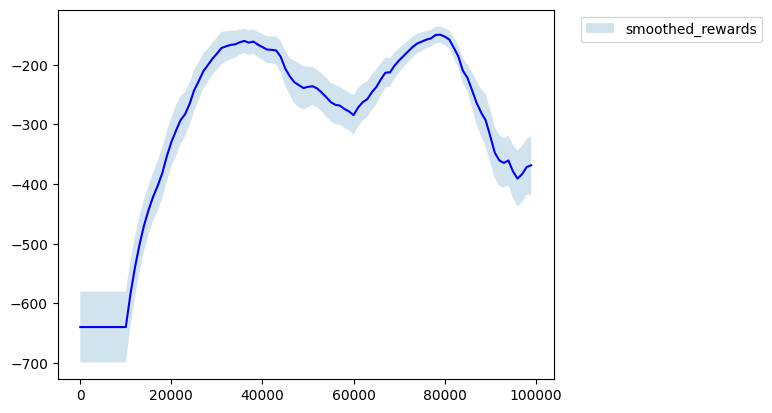

<Figure size 640x480 with 0 Axes>

In [10]:
dqn = DQN(args)
result_means_dqn, result_stds_dqn = train_dqn(dqn)
plot_results(result_means_dqn, result_stds_dqn)

Here the goal is to implement the epsilon-gredy strategy. With probability epsilon we choose uniformly a random action and with probability 1-epsilon we take the action with the highest Q-value according to the main critic.

In [11]:
class EpsilonGreedyDQN(DQN):
  def __init__(self, args):
    super(EpsilonGreedyDQN, self).__init__(args)
    self.epsilon = 0.1 # best one found

  def explore(self, states):
    rand = np.random.rand(states.shape[1])
    use_greedy = (rand >= self.epsilon)

    explore_actions = super().explore(states)
    greedy_action = self.get_greedy_action(states.squeeze(0))
    
    actions = np.where(use_greedy, greedy_action, explore_actions)
    return actions

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -409.68117937193114; eval_std: 26.826610755941026
Training step: 12000
Eval mean: -117.41175940683627

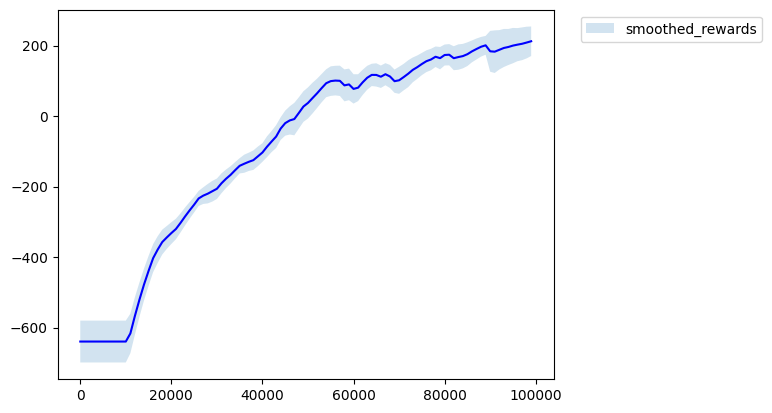

<Figure size 640x480 with 0 Axes>

In [12]:
epsilon_greedy_dqn = EpsilonGreedyDQN(args)
result_means_epsilon_greedy_dqn, result_stds_epsilon_greedy_dqn = train_dqn(epsilon_greedy_dqn)
plot_results(result_means_epsilon_greedy_dqn, result_stds_epsilon_greedy_dqn)

I created the plos for multiple hyperparameters in a separet notebook. Otherwise, it would take a few hours for all computations to complete.

I checked a few values of epsilon, can be seen in the plot below.
It seems like the 0.1 epislon is the best one though 0.2 is not far behind and is learning faster in the beginning. For epsilon 0.05 we don't explore enough and don't reach the desired performance (~200 points).

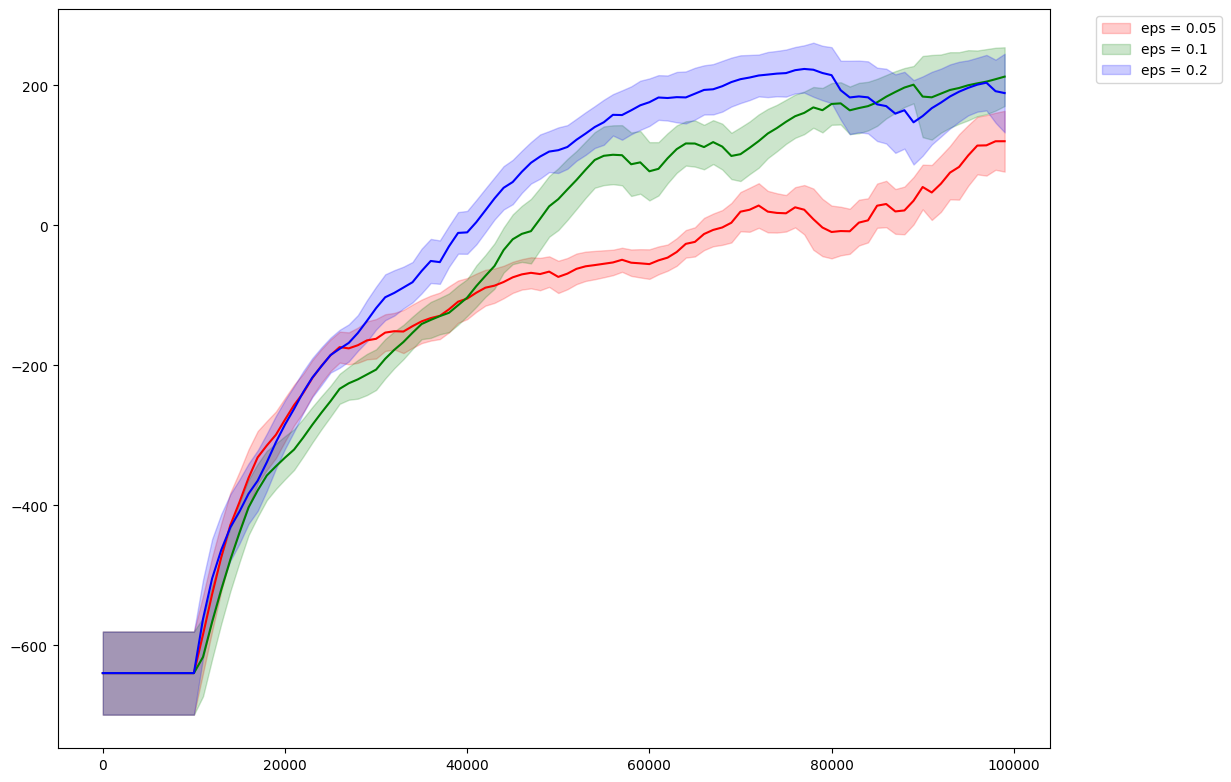

Here we add to the epsilon-greedy strategy epsilon annealing. We change linearly epsilon from 1.0 to the value final_epsilon during first anneal_steps steps and then it remains on the final_epsilon level.
Such an approach aims to increase the exploration level at the beginning of the training, when the Q-value estimate is poor and thus choosing greedily according to Q is not improving the performance.

In [13]:
class EpsilonGreedyWithAnnealingDQN(EpsilonGreedyDQN):
  def __init__(self, args):
    self.start_epsilon = 1.0
    super(EpsilonGreedyWithAnnealingDQN, self).__init__(args)
    
    self.epsilon = self.start_epsilon
    self.final_epsilon = 0.1 # best one found
    self.annealing = True
    self.anneal_steps = 30000

  def anneal(self, step):
    step += 1 # so that on step 0 we actually anneal
    if step >= self.anneal_steps:
      self.epsilon = self.final_epsilon
    else:
      e1 = self.final_epsilon * step / self.anneal_steps
      e2 = self.start_epsilon * (1 - step / self.anneal_steps)
      self.epsilon = e1 + e2

  def reset(self):
    super(EpsilonGreedyWithAnnealingDQN, self).reset()
    self.epsilon = self.start_epsilon

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -96.72984502708817; eval_std: 7.944462272261691
Training step: 12000
Eval mean: -91.81972320647783; e

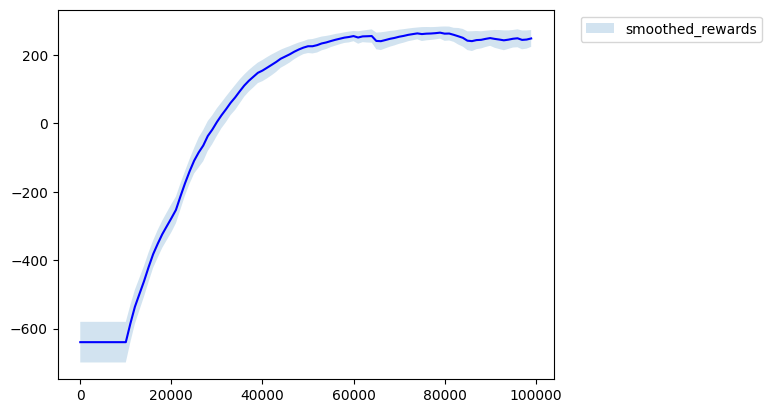

<Figure size 640x480 with 0 Axes>

In [14]:
epsilon_greedy_with_annealing_dqn = EpsilonGreedyWithAnnealingDQN(args)
result_means_epsilon_greedy_with_annealing_dqn, result_stds_epsilon_greedy_with_annealing_dqn = train_dqn(epsilon_greedy_with_annealing_dqn)
plot_results(result_means_epsilon_greedy_with_annealing_dqn, result_stds_epsilon_greedy_with_annealing_dqn)

Here we converge with all epsilon values except for 0.5 which prevents exploitation in the later stages of training.

For smaller epsilons, we converge to a very similar performance. The 0.1 final epsilon is the best one. In the end it's slightly below the 0.05 final epsilon but it learns mmuch faster and the difference is negligible.

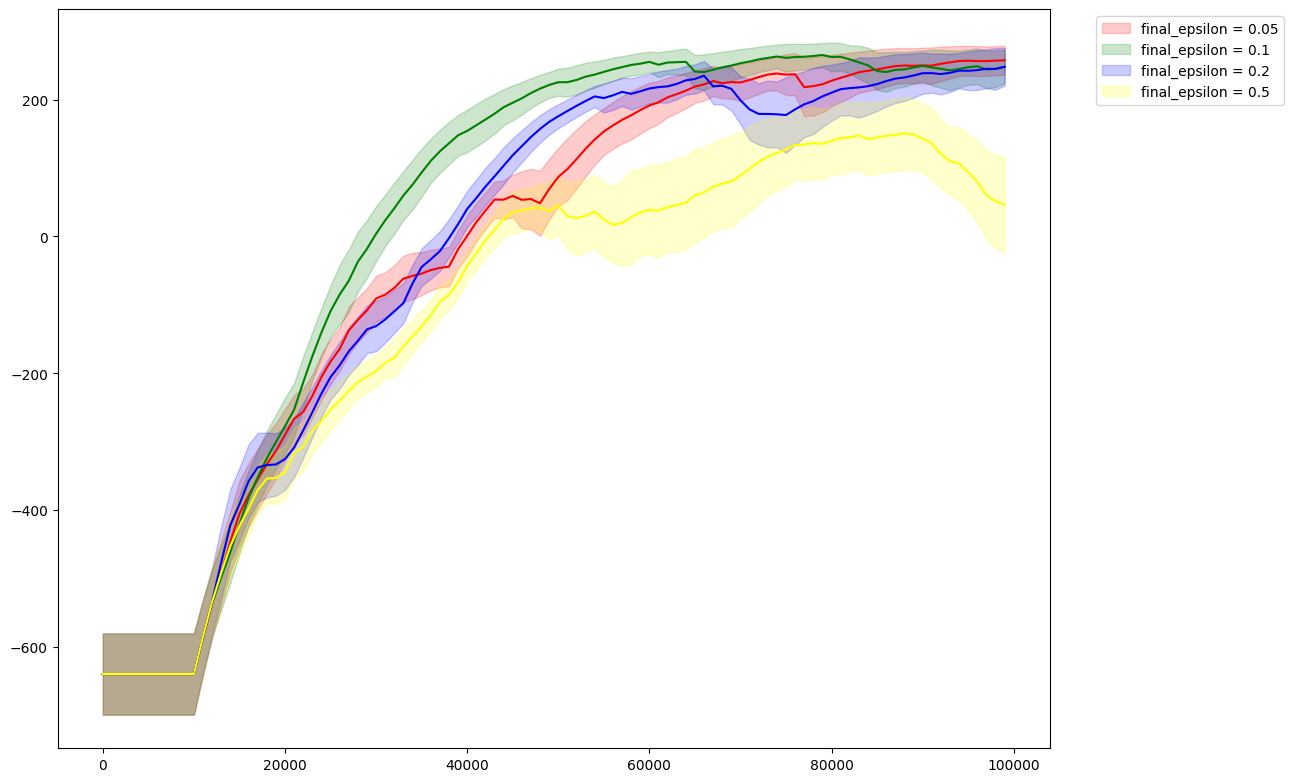

Alternative approach to the epsilon-greedy strategy is to use so-called boltzmann exploration strategy.
The idea behind this approach is to perform softmax on the Q-values coming from the main critic and then sample from the obtained distribution.
In this approach we use softmax with a temperature, i.e. before applying softmax, we scale all the Q-values by the temperature coefficient (in the literature we usually divide by the temperature, but this is equivallent to scaling by the inverse of the temperature). Large scaling values make the distribution close to the greedy choice, while low scaling values make the distribution close to the uniform one.

In [15]:
class BoltzmannDQN(DQN):
  def __init__(self, args):
    super(BoltzmannDQN, self).__init__(args)
    self.temperature = 2.0 # best one found (leanrs much faster than 5.0, yields very similar result)

  def explore(self, states):
    action = None
    with torch.no_grad():
      q_values = self.q_net(states)
      logits = q_values * self.temperature
      sm = torch.nn.functional.softmax(logits, dim=-1)
      
      (_, _, action_size) = sm.size()
      action = torch.multinomial(sm.view(-1, action_size), num_samples=1)
      action = action.reshape(-1).detach().cpu().numpy()

    return action

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -115.39218463086024; eval_std: 11.130378756035272
Training step: 12000
Eval mean: -87.97216300671217;

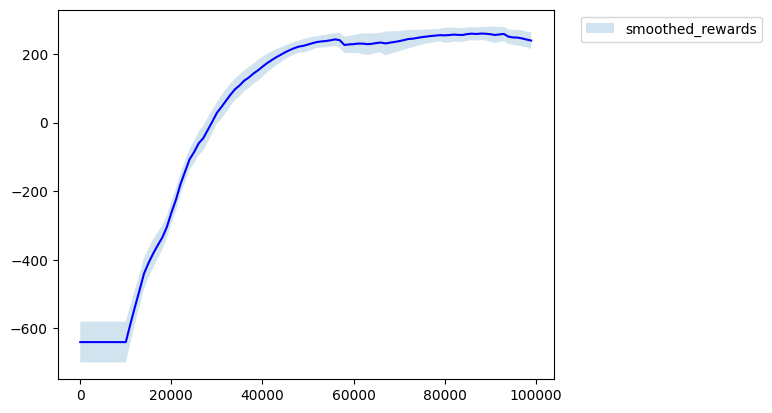

<Figure size 640x480 with 0 Axes>

In [16]:
boltzmann_dqn = BoltzmannDQN(args)
result_means_boltzmann_dqn, result_stds_boltzmann_dqn = train_dqn(boltzmann_dqn)
plot_results(result_means_boltzmann_dqn, result_stds_boltzmann_dqn)

I will refer to the value that we are tuning in Boltzmann stategies as 'temperature' (with ''). The task description tells to use 'temperature' = 1/temperature, since normally in softmax we divide logits by temperature and here we have to multiply by it.

For Boltzmann we get the best results for big 'temperature' values. Traings with small 'temperature' values don't exploit enough.


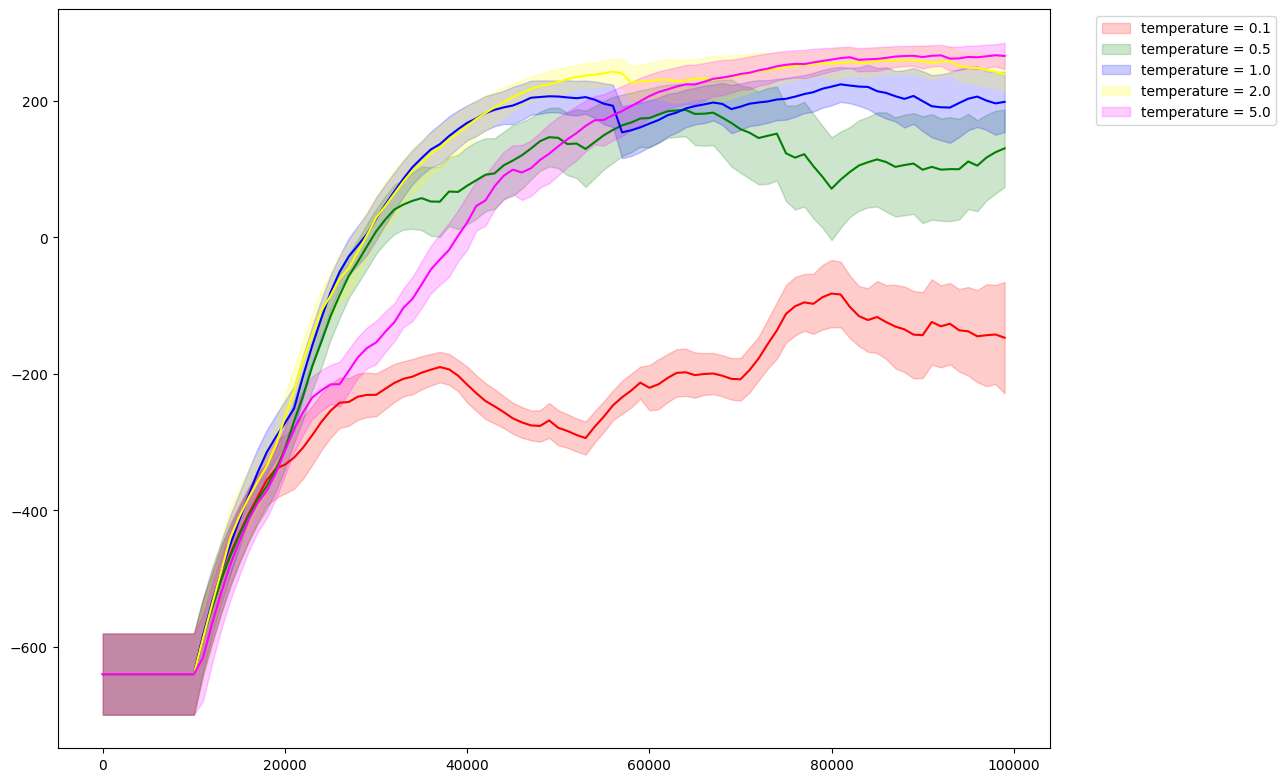

One of the compromises between epsilon-greedy and boltzmann exploration strategy is so-calles max-boltzmann strategy. In this strategy with probability 1-epsilon we choose action greedily, but with probability epsilon we perform the boltzmann choice instead of the uniform random choice.

In [17]:
class MaxBoltzmannDQN(EpsilonGreedyWithAnnealingDQN):
  def __init__(self, args):
    super(MaxBoltzmannDQN, self).__init__(args)
    self.temperature = 0.5 # best one found

  def explore(self, states):
    rand = np.random.rand(states.shape[1])
    use_greedy = (rand >= self.epsilon)
    with torch.no_grad():
        actions_greedy = self.get_greedy_action(states.squeeze(0))

        q_values = self.q_net(states)
        logits = q_values * self.temperature
        sm = torch.nn.functional.softmax(logits, dim=-1)
        (_, _, action_size) = sm.size()
        actions_boltzmann = torch.multinomial(sm.view(-1, action_size), num_samples=1)
        actions_boltzmann = actions_boltzmann.reshape(-1).detach().cpu().numpy()

        actions = np.where(use_greedy, actions_greedy, actions_boltzmann)
    return actions

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -85.79326669020402; eval_std: 8.884583366798978
Training step: 12000
Eval mean: -60.58424361565606; e

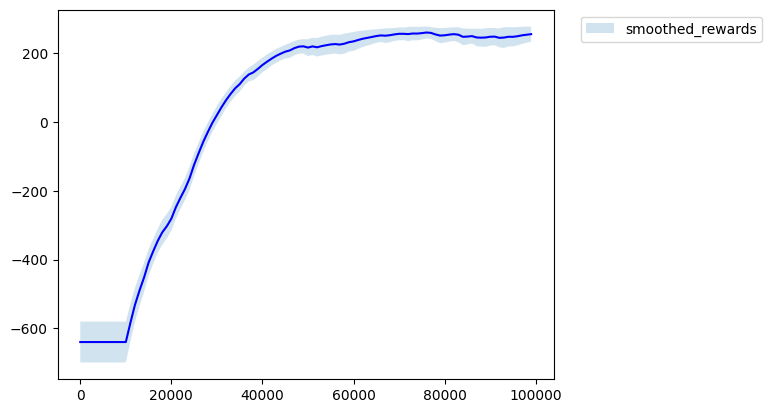

<Figure size 640x480 with 0 Axes>

In [18]:
max_boltzmann_dqn = MaxBoltzmannDQN(args)
result_means_max_boltzmann_dqn, result_stds_max_boltzmann_dqn = train_dqn(max_boltzmann_dqn)
plot_results(result_means_max_boltzmann_dqn, result_stds_max_boltzmann_dqn)

For max Boltzmann the influence of 'temperature' is very small. We get very similar results for all tested 'temperature' values.

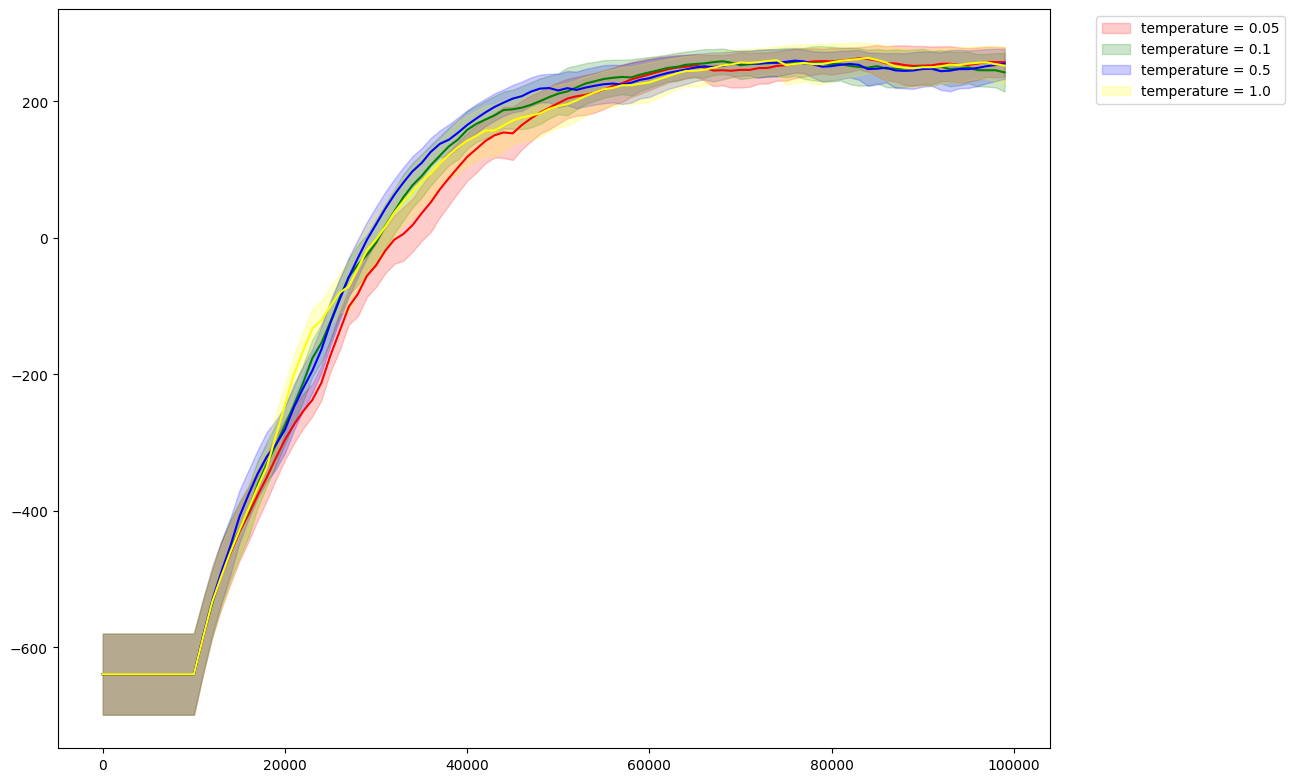

Similarly to adjusting the value of epsilon in epsilon-greedy strategy, we can adjust the temperature in the max-boltzmann and boltzmann strategies: we start we the value start_temperature and linearly increase the value to the final_temperature during temperature_anneal_steps, then the temperature is on the constant level.


In [19]:
class MaxBoltzmannWithTemperatureAnnealingDQN(MaxBoltzmannDQN):
  def __init__(self, args):
    self.start_temparature = 0.01 # best one found
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temparature
    self.final_temperature = 0.5 # best one found
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).anneal(step)
    step += 1 # so that on step 0 we actually anneal
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      t1 = self.final_temperature * step / self.temperature_anneal_steps
      t2 = self.start_temparature * (1 - step / self.temperature_anneal_steps)
      self.temperature = t1 + t2

  def reset(self):
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).reset()
    self.temperature = self.start_temparature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -75.52076475876383; eval_std: 7.427624255908536
Training step: 12000
Eval mean: -50.71573773640453; e

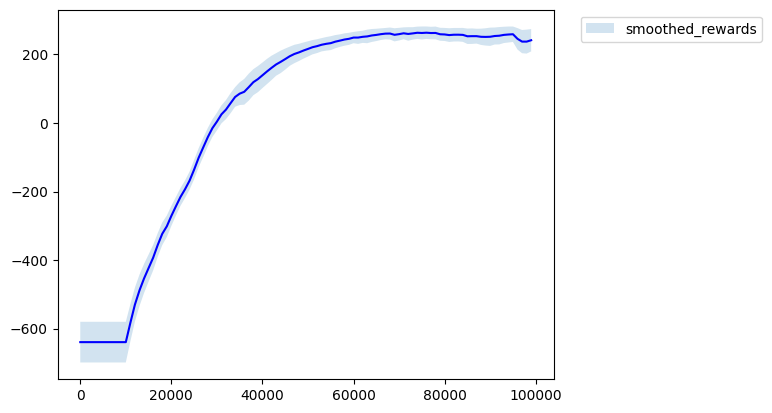

<Figure size 640x480 with 0 Axes>

In [20]:
max_boltzmann_temp_anneal_dqn = MaxBoltzmannWithTemperatureAnnealingDQN(args)
result_means_max_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn = train_dqn(max_boltzmann_temp_anneal_dqn)
plot_results(result_means_max_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn)

The results are very similar to the non-annealed version. The differences that can be observed are a result of the randomness of in the training process.

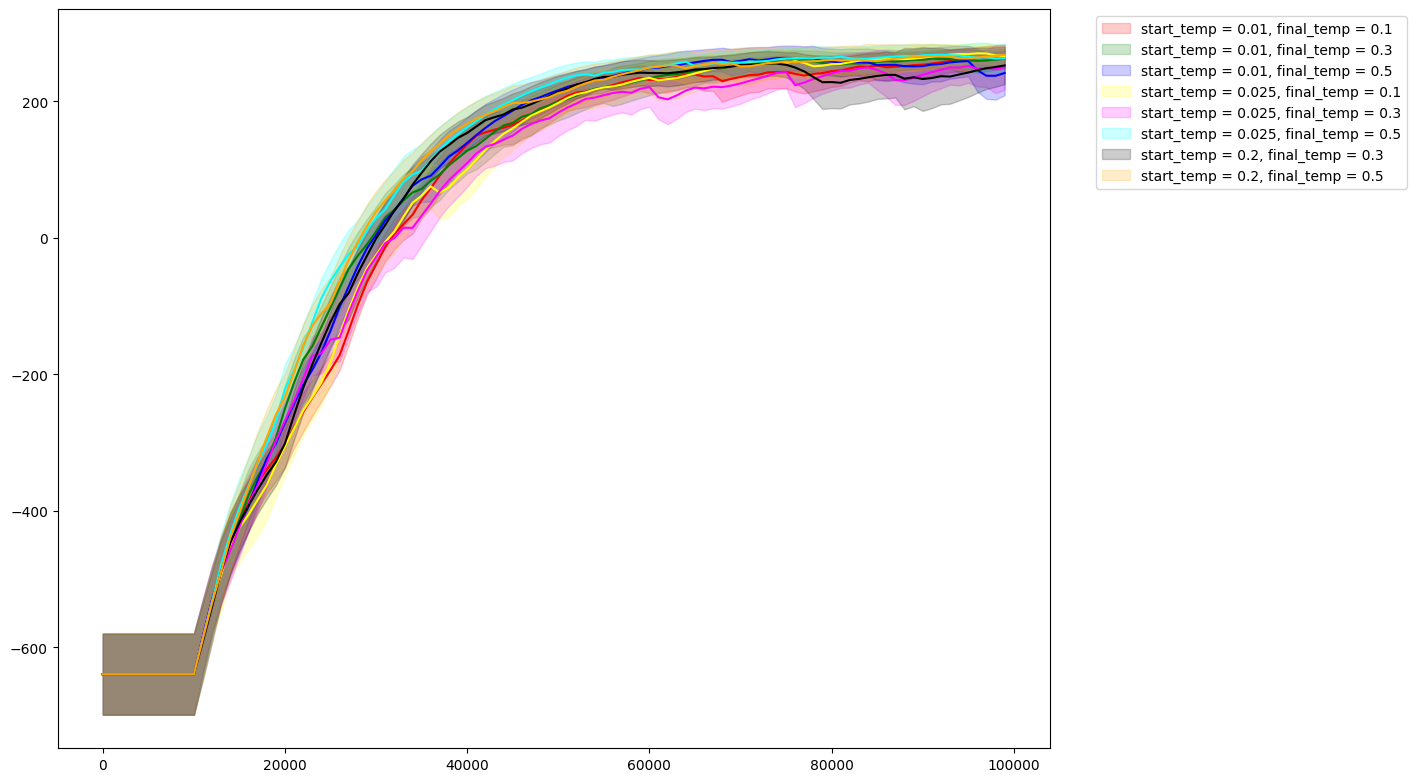

In [21]:
class BoltzmannWithTemperatureAnnealingDQN(BoltzmannDQN):
  def __init__(self, args):
    self.start_temparature = 0.1 # best one found
    super(BoltzmannWithTemperatureAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temparature
    self.final_temperature = 5.0 # best one found
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    step += 1 # so that on step 0 we actually anneal
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      t1 = self.final_temperature * step / self.temperature_anneal_steps
      t2 = self.start_temparature * (1 - step / self.temperature_anneal_steps)
      self.temperature = t1 + t2

  def reset(self):
    super(BoltzmannWithTemperatureAnnealingDQN, self).reset()
    self.temperature = self.start_temparature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -52.20287687408456; eval_std: 7.247814547289538
Training step: 12000
Eval mean: -62.247764937377475; 

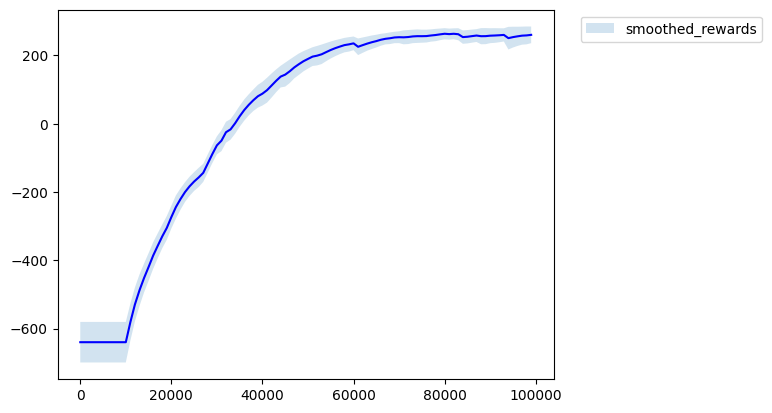

<Figure size 640x480 with 0 Axes>

In [22]:
boltzmann_temp_anneal_dqn = BoltzmannWithTemperatureAnnealingDQN(args)
result_means_boltzmann_temp_anneal_dqn, result_stds_boltzmann_temp_anneal_dqn = train_dqn(boltzmann_temp_anneal_dqn)
plot_results(result_means_boltzmann_temp_anneal_dqn, result_stds_boltzmann_temp_anneal_dqn)

It seems like most of the tarinings converged to a similar result. Most of the trained models can succesfuly sove the task (achieve ~200 points). There are some with worse values - I suppose it's due to too low final 'temperature' (so the models don't exploit enough).

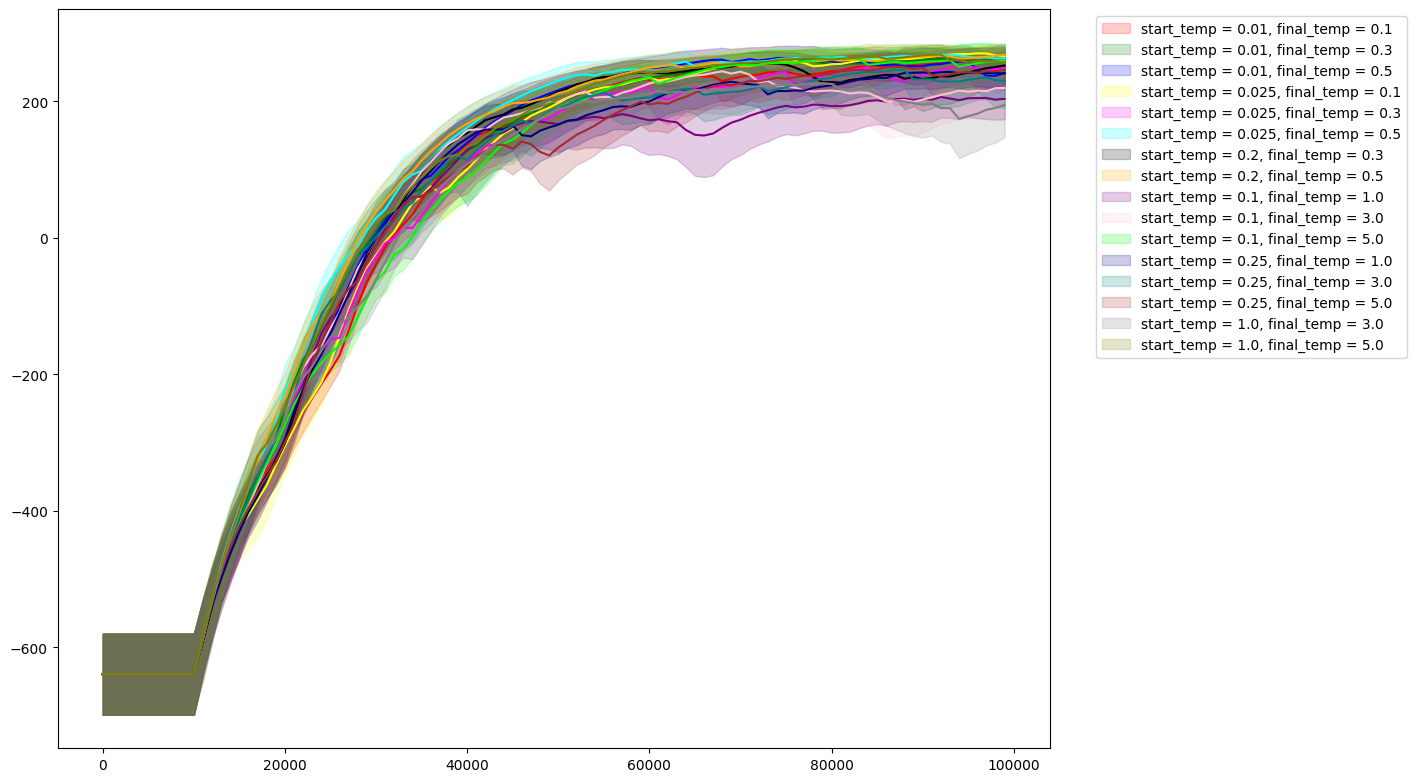

The last exploration idea we want to implement is a combintation of the epsilon-greedy strategy (with epsilon annealing) and the boltzmann strategy.
We could think that at the beginning of the training the boltzmann strategy struggles because the Q-function (the main critic) is not yet well-trained. However, the more critic is trained, the more sense it makes to start using the boltzmann strategy. We would like to verif y this hypoothesis by using in the first half of the training epsilon-greedy strategy (with epsilon annealing) and in the second half of the training switch the exploration strategy to the boltzmann one.

In [23]:
def train_two_halfs_dqn(dqn_1, dqn_2):
  set_seed(TRAIN_SEED)
  
  dqn_1.final_epsilon = 0.1 # best one found
  dqn_2.temperature = 1.0 # best one found
  
  result_mean_1, result_std_1 = dqn_1.train()

  dqn_2.q_net.load_state_dict(dqn_1.q_net.state_dict())
  dqn_2.q_target.load_state_dict(dqn_1.q_target.state_dict())

  result_mean_2, result_std_2 = dqn_2.train()

  dqn_1.q_net.load_state_dict(dqn_2.q_net.state_dict())
  dqn_1.q_target.load_state_dict(dqn_2.q_target.state_dict())

  result_mean = np.concatenate([result_mean_1, result_mean_2])
  result_std = np.concatenate([result_std_1, result_std_2])

  return result_mean, result_std


Training step: 0
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 1000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 2000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 3000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 4000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 5000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 6000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 7000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 8000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 9000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 10000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 11000
Eval mean: -32.46066623925785; eval_std: 36.891417336568864
Training step: 12000
Eval mean: -53.89129364017921; 

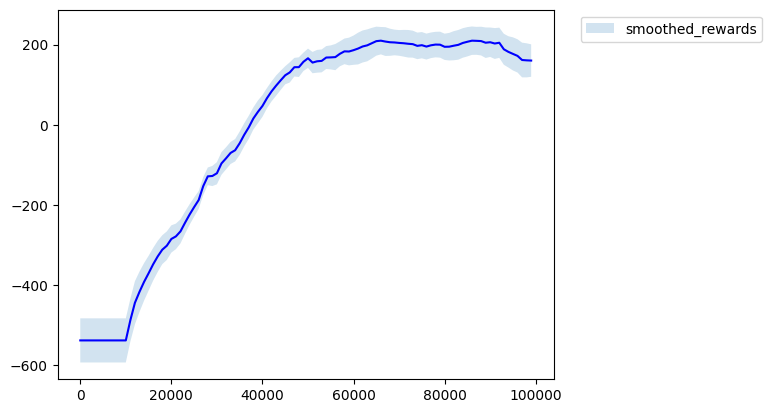

<Figure size 640x480 with 0 Axes>

In [24]:
epsilon_greedy_with_annealing_half_dqn = EpsilonGreedyWithAnnealingDQN(first_half_training_args) # investigate sensitivity of epsilon
epsilon_greedy_boltzmann_half_dqn = BoltzmannDQN(second_half_training_args) # investigate sensitivity of temperature
result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn = train_two_halfs_dqn(epsilon_greedy_with_annealing_half_dqn, epsilon_greedy_boltzmann_half_dqn)
plot_results(result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn)

The best performance is obtained with small epsilon (0.1) and big temperature (1.0). These values are good exploration-exploitation trade-off points.

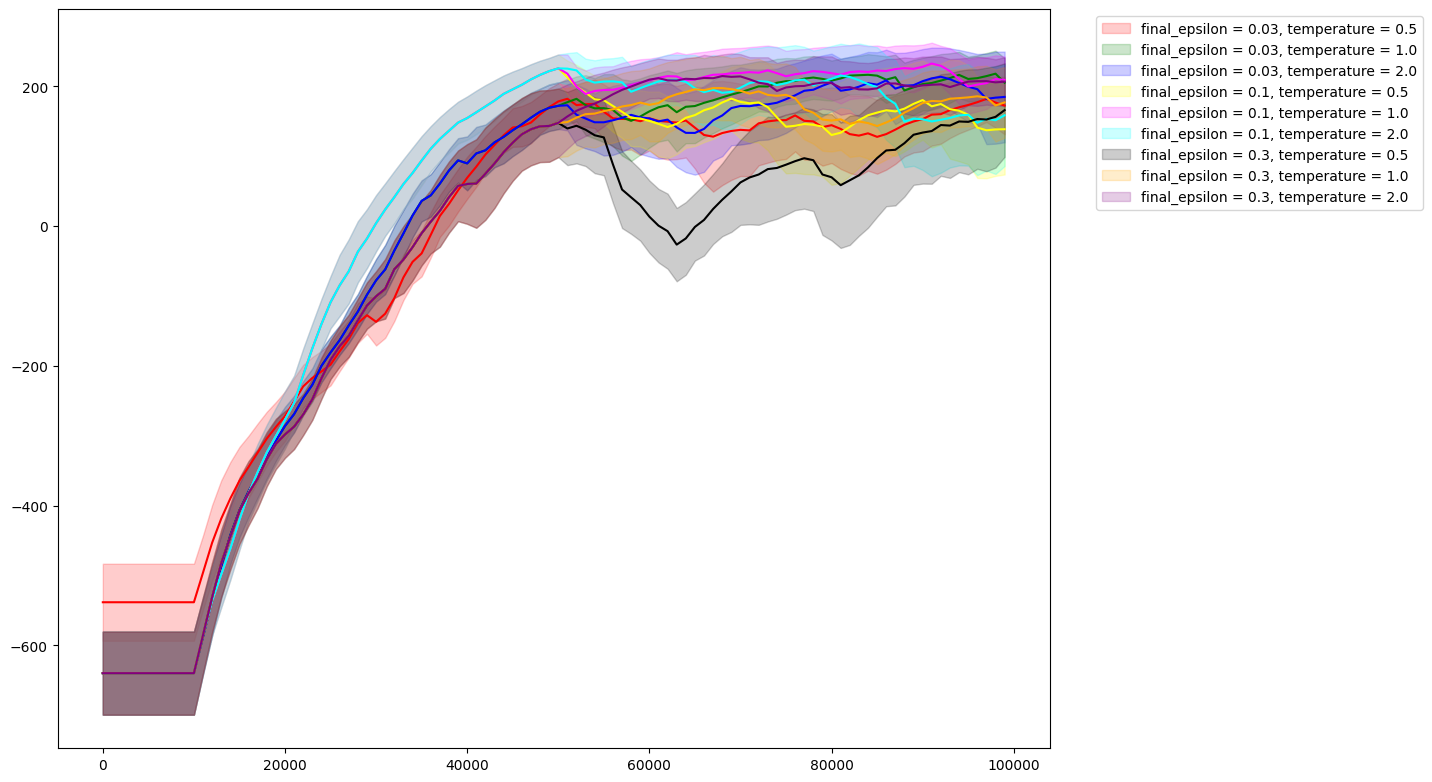

### Extra task

#### Combining epsilon-greedy with boltzmann strategy

Each round I will randomly select whether to use epsilon-greedy or boltzmann strategy. In the begginning of the training I will use epsilon-greedy with probability 1.0 and in the end of the training I will use boltzmann with probability 1.0. In between I will linearly change the probability of choosing either strategy.

In [25]:
class EpsGreedyAndBoltzmannMixingDQN(EpsilonGreedyWithAnnealingDQN):
    def __init__(self, args):
        super().__init__(args)
        self.temperature = 2.0
        self.explore_boltzmann = BoltzmannDQN.explore
        self.explore_eps_greedy = EpsilonGreedyWithAnnealingDQN.explore
        self.p = 1.0
        self.p_anneal_steps = 90000
        self.final_epsilon = 0.1

    def explore(self, states):
        rand = np.random.rand(states.shape[1])
        use_boltzmann = (rand >= self.p)

        eps_greedy_actions= self.explore_eps_greedy(self, states)
        boltzmann_actions = self.explore_boltzmann(self, states)

        actions = np.where(use_boltzmann, boltzmann_actions, eps_greedy_actions)
        return actions

    def anneal(self, step):
        step += 1
        self.p = 1.0 - step / self.p_anneal_steps
        self.p = max(self.p, 0)
        super().anneal(step)
    def reset(self):
        self.p = 1.0
        self.epsilon = 1.0
        super().reset()

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -115.46934565570702; eval_std: 7.0152819683156045
Training step: 12000
Eval mean: -137.43879765949404

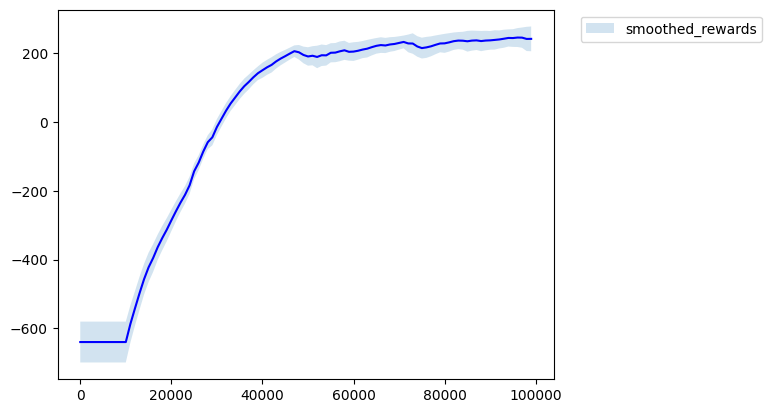

<Figure size 640x480 with 0 Axes>

In [26]:
mixed_dqn = EpsGreedyAndBoltzmannMixingDQN(args)
result_means_mixed_dqn, result_stds_mixed_dqn = train_dqn(mixed_dqn)
plot_results(result_means_mixed_dqn, result_stds_mixed_dqn)

Let's plot it with the two halves training to see if we have an improvement.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -587.26824754 -542.28530255 -498.37130632 -457.23158473
 -422.51803939 -395.37971524 -363.9700364  -337.44566077 -312.98311088
 -285.95502629 -259.70458356 -234.65621171 -211.84872581 -184.29077411
 -143.46622505 -118.18560299  -86.15031678  -58.80219019  -44.66007573
  -14.6927047     8.99322583   32.53544953   53.36433086   70.9108402
   88.43873738  103.78165969  116.2207461   129.72155725  141.51687276
  150.23227578  158.71340517  165.8160553   175.90743497  184.15967152
  191.21365431  198.61647563  205.68172479  202.50573023  194.73754687
  190.31952103  192.3905403   188.91168202  193.8564709   193.50831003
  201.04734155  201.52697952  205.29080769  208.21594852  203.82106005
  204.47635415  206.93539981  210.35728083  212.93521098  217.3223887
  221.17273995  223.42522664  222.249049    225.16568896  226.67569489
  229.63

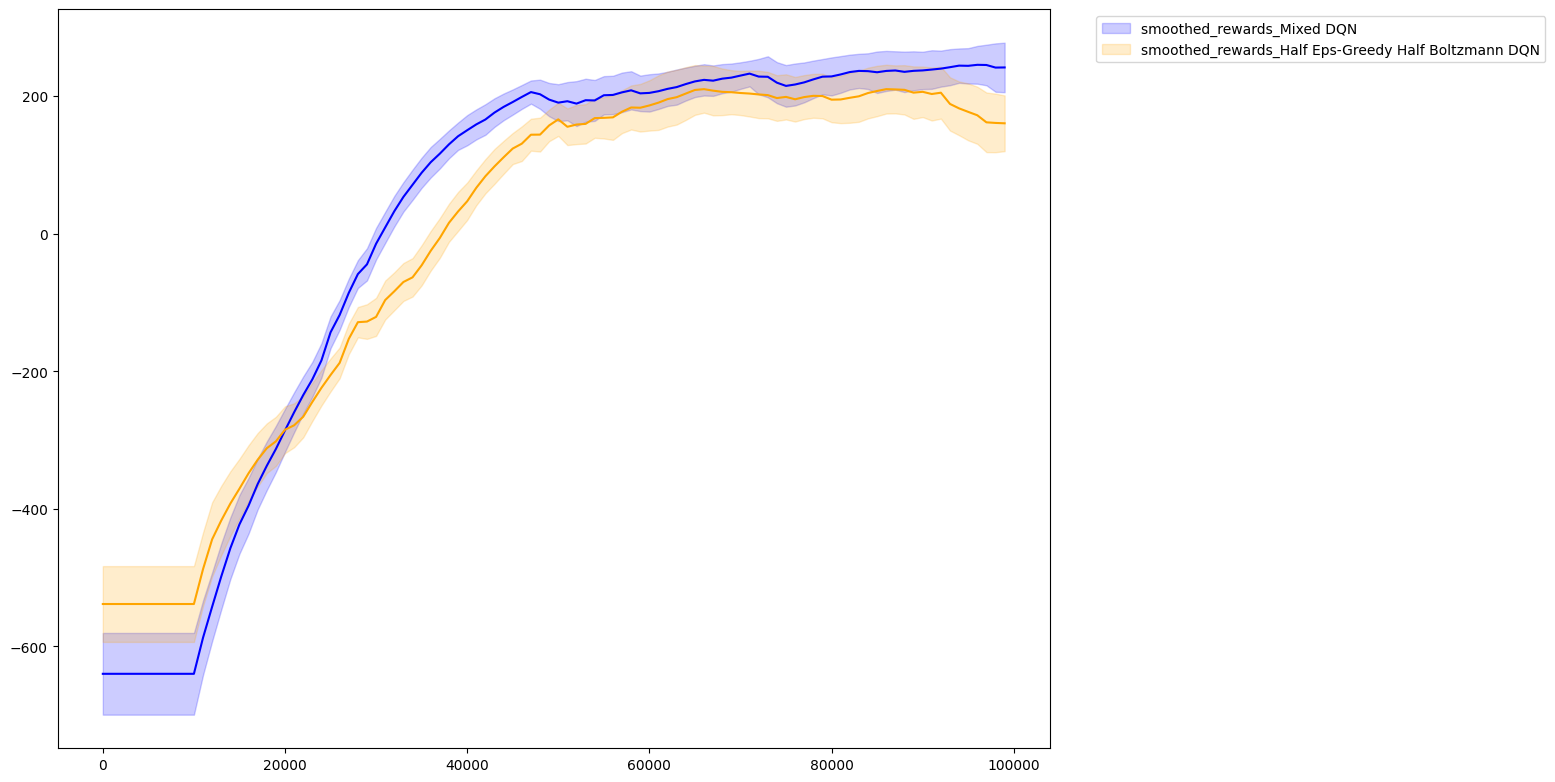

<Figure size 640x480 with 0 Axes>

In [27]:
means_list = [result_means_mixed_dqn, result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
stds_list = [result_stds_mixed_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
names_list = ["Mixed DQN", "Half Eps-Greedy Half Boltzmann DQN"]
colours_list = ["blue", "orange"]
plot_results_many(means_list, stds_list, names_list, colours_list)

We can see that this mixing resulted in a slightly better model. The model has a bit worse start but outperforms the two halves training quickly.

#### Another temperature annealing strategy

In deep learning it is often better to use cosine LR scheduler instead of linear one. This way we get a bit more time with the start LR and with the final LR. Let's check how well it is going to work with the temperature annealing.

In [28]:
class BoltzmannWithTemperatureCosineAnnealingDQN(BoltzmannDQN):
  def __init__(self, args):
    self.start_temparature = 0.1
    super(BoltzmannWithTemperatureCosineAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temparature
    self.final_temperature = 5.0
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    step += 1 # so that on step 0 we actually anneal
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      cos = np.cos(np.pi * step / self.temperature_anneal_steps)
      cos = (cos + 1) / 2
      self.temperature = self.final_temperature + (self.start_temparature - self.final_temperature) * cos 

  def reset(self):
    super(BoltzmannWithTemperatureCosineAnnealingDQN, self).reset()
    self.temperature = self.start_temparature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -69.64391100516994; eval_std: 27.743356533895366
Training step: 12000
Eval mean: -78.14029110026364; 

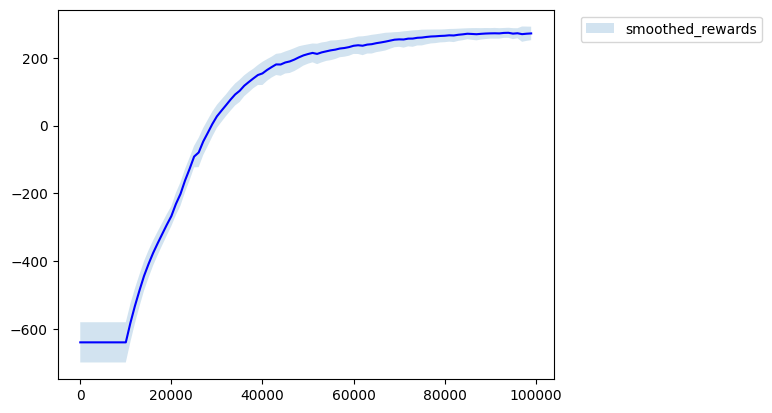

<Figure size 640x480 with 0 Axes>

In [29]:
boltzmann_temp_cos_anneal_dqn = BoltzmannWithTemperatureCosineAnnealingDQN(args)
result_means_boltzmann_temp_cos_anneal_dqn, result_stds_boltzmann_temp_cos_anneal_dqn = train_dqn(boltzmann_temp_cos_anneal_dqn)
plot_results(result_means_boltzmann_temp_cos_anneal_dqn, result_stds_boltzmann_temp_cos_anneal_dqn)

Let's also check cosine with restarts - model has chance to learn a new approach and then exploit it many times.

In [30]:
class BoltzmannWithTemperatureCosineRestartsAnnealingDQN(BoltzmannDQN):
  def __init__(self, args):
    self.start_temparature = 0.5
    super(BoltzmannWithTemperatureCosineRestartsAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temparature
    self.final_temperature = 5.0
    self.temperature_anneal_steps = 10000
    self.annealing = True

  def anneal(self, step):
    step += 1 # so that on step 0 we actually anneal
    step = step % self.temperature_anneal_steps
    
    cos = np.cos(np.pi * step / self.temperature_anneal_steps)
    cos = (cos + 1) / 2
    self.temperature = self.final_temperature + (self.start_temparature - self.final_temperature) * cos 

  def reset(self):
    super(BoltzmannWithTemperatureCosineRestartsAnnealingDQN, self).reset()
    self.temperature = self.start_temparature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -78.27381729394949; eval_std: 10.066732266308572
Training step: 12000
Eval mean: -123.77226381735757;

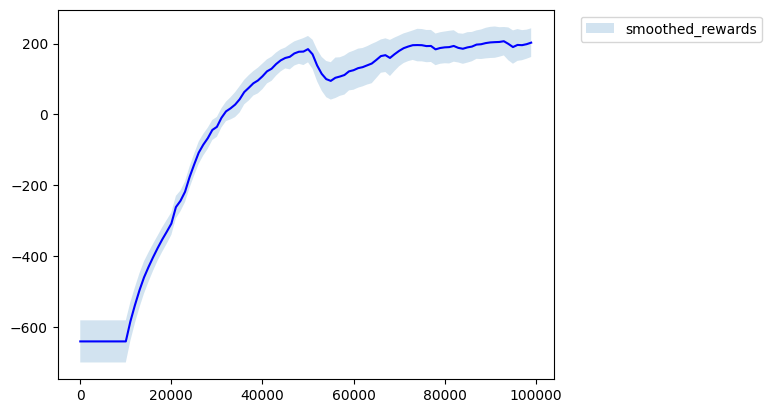

<Figure size 640x480 with 0 Axes>

In [31]:
boltzmann_temp_cos_res_anneal_dqn = BoltzmannWithTemperatureCosineRestartsAnnealingDQN(args)
result_means_boltzmann_temp_cos_res_anneal_dqn, result_stds_boltzmann_temp_cos_res_anneal_dqn = train_dqn(boltzmann_temp_cos_res_anneal_dqn)
plot_results(result_means_boltzmann_temp_cos_res_anneal_dqn, result_stds_boltzmann_temp_cos_res_anneal_dqn)

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -582.68570408 -532.23116278 -486.59652299 -443.70029447
 -408.19608503 -375.83846638 -347.23689305 -319.86096401 -292.72952447
 -267.10766934 -231.26510223 -201.8955491  -162.12786334 -127.96611052
  -91.38039468  -79.37772404  -46.8635036   -21.38121333    4.67135655
   27.28503814   43.90850007   60.16398128   76.67884324   91.80507608
  102.62795306  117.58868679  128.56599471  139.10695341  149.19080154
  153.95645412  164.01003369  172.49645478  180.45250138  180.26944961
  186.184076    189.32444343  194.74397174  201.40508881  207.13761154
  211.14179547  214.46763294  211.50213492  215.97657435  219.0830669
  222.04721681  224.13967463  227.41854809  228.95166     231.5735124
  235.46125838  237.04536215  235.66139188  238.97630131  240.24073868
  243.18614098  245.31246507  247.75934641  250.61164481  253.46788224
  254.40

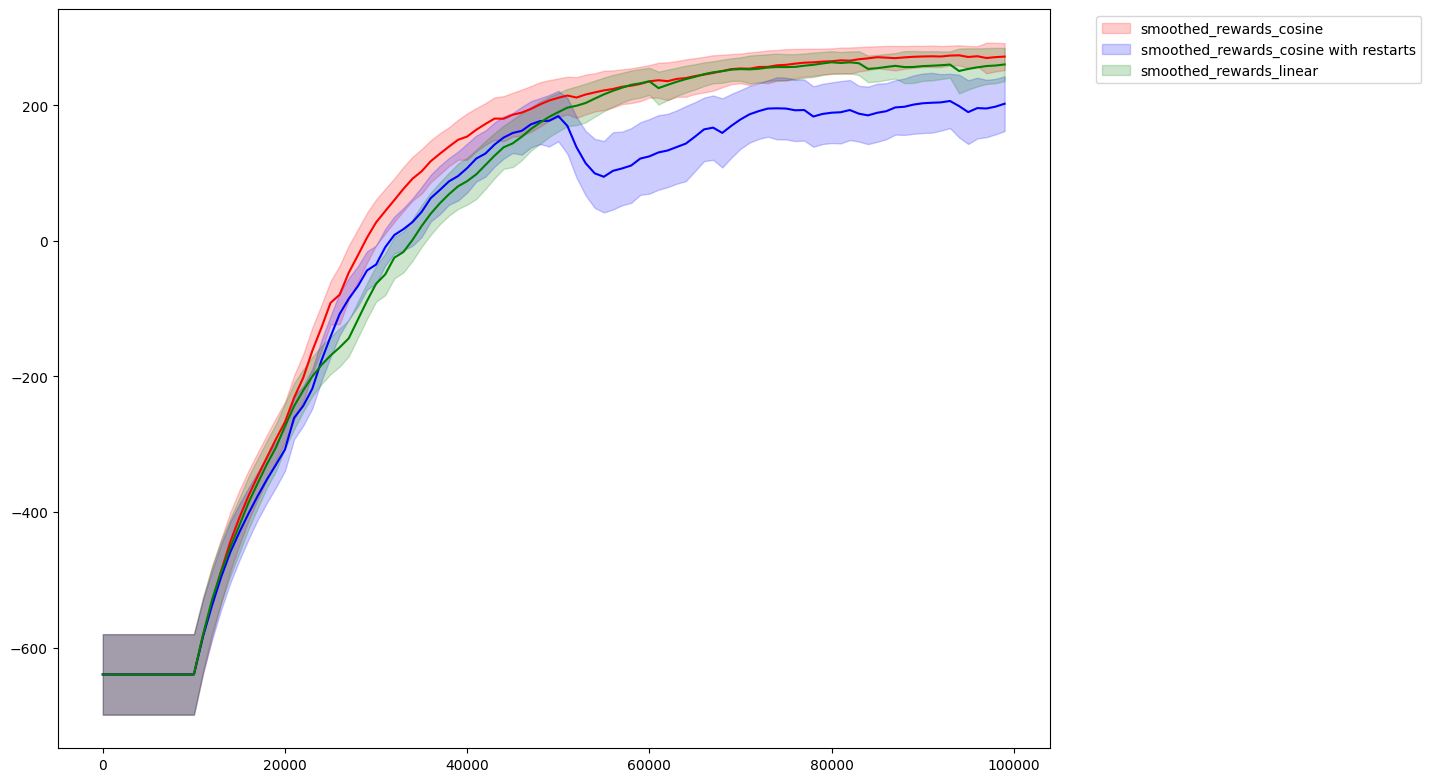

<Figure size 640x480 with 0 Axes>

In [32]:
result_means_list = [
    result_means_boltzmann_temp_cos_anneal_dqn,
    result_means_boltzmann_temp_cos_res_anneal_dqn,
    result_means_boltzmann_temp_anneal_dqn
]
result_stds_list = [
    result_stds_boltzmann_temp_cos_anneal_dqn,
    result_stds_boltzmann_temp_cos_res_anneal_dqn,
    result_stds_boltzmann_temp_anneal_dqn
]
names_list = ['cosine', 'cosine with restarts', 'linear']
colours_list = ["red", "blue", "green"]
plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

As we can see, cosine decay is slightly better than linear, improves results especially in the early stages of the training (when the decays actually happen). The restarts don't work so well because we don't have time in the end to exploit the task.

### Conclusions

Here we plot the results of all exploration methods on one plot. However, for drawing conclusions, it might be reasonable to plot some subsets of methods together, for example to compare variants with and without annealing, max-boltzmann with boltzmann, epsilon-greedy, boltzmann and half-epsilon-greedy, half-boltzmann.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -585.14569421 -540.03990527 -501.74488511 -469.31901932
 -443.2744036  -421.02741294 -402.83078247 -381.73313007 -353.50702805
 -329.51675671 -310.64640434 -292.89253479 -282.88361429 -265.56304788
 -242.69451334 -227.53670297 -210.9790205  -200.55447976 -189.96728148
 -181.21003079 -171.82478178 -169.02009176 -166.50498065 -165.68691672
 -162.21160593 -159.91008472 -162.7849101  -160.98160161 -166.13870887
 -170.171749   -174.34632713 -174.89024645 -175.78374925 -186.29608667
 -206.10176513 -219.2558915  -229.11375745 -234.13441266 -238.84989448
 -236.92020061 -235.83738629 -239.57584954 -246.43504566 -254.20926006
 -262.56352049 -266.94718256 -268.36465223 -274.03404882 -278.02078302
 -284.28509665 -271.6209233  -262.58861949 -257.75261944 -246.1722367
 -237.24383213 -224.32165755 -213.09760355 -212.68179901 -201.26962708
 -192.5

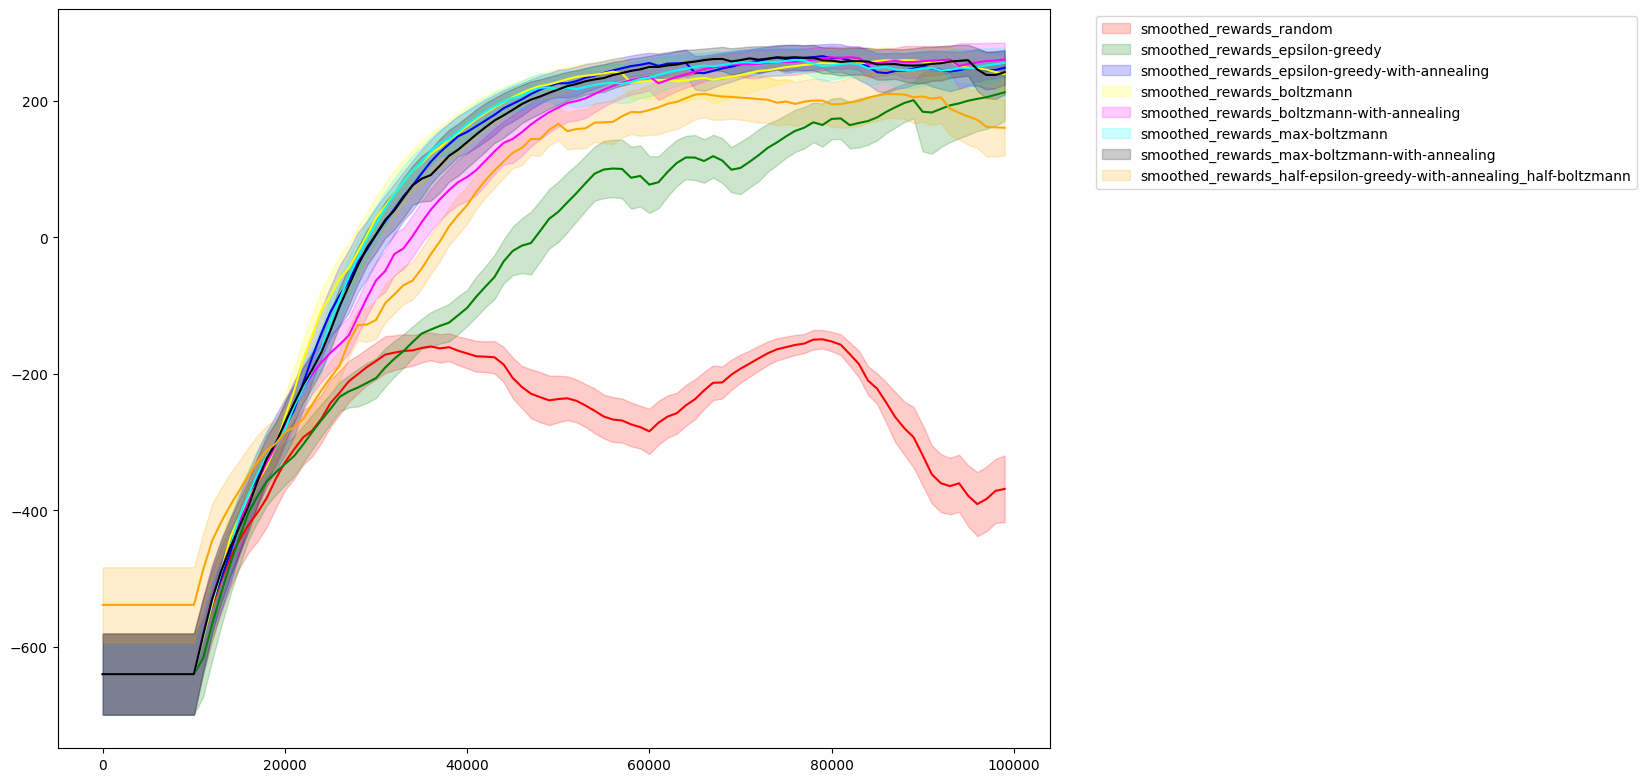

<Figure size 640x480 with 0 Axes>

In [33]:
result_means_list = [result_means_dqn, result_means_epsilon_greedy_dqn, result_means_epsilon_greedy_with_annealing_dqn,
                result_means_boltzmann_dqn, result_means_boltzmann_temp_anneal_dqn,
                result_means_max_boltzmann_dqn, result_means_max_boltzmann_temp_anneal_dqn,
                result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
result_stds_list = [result_stds_dqn, result_stds_epsilon_greedy_dqn, result_stds_epsilon_greedy_with_annealing_dqn,
                result_stds_boltzmann_dqn, result_stds_boltzmann_temp_anneal_dqn,
                result_stds_max_boltzmann_dqn, result_stds_max_boltzmann_temp_anneal_dqn,
                result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
names_list = ["random", "epsilon-greedy", "epsilon-greedy-with-annealing",
             "boltzmann", "boltzmann-with-annealing",
             "max-boltzmann", "max-boltzmann-with-annealing",
             "half-epsilon-greedy-with-annealing_half-boltzmann"]
colours_list = ["red", "green", "blue",
           "yellow", "magenta",
           "cyan", "black",
           "orange"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

### Comments on the results

We can see that all exploration starategies are very beneficial. More sophisticated exploration strategies generally lead to better results.

Epsilon greedy strategies worked signifintly worse. The two halves training performed slightly worse then the other trainings. Boltzmann with annealing also seems to learn a bit slower in the middle of the training.

If we look only at the epsilon-greedy strategies:

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -616.68943091 -566.76166376 -520.59724501 -477.71069369
 -439.17412772 -403.05882771 -378.77744206 -357.47627437 -344.33553295
 -331.96789766 -320.38056641 -303.30016092 -285.01469875 -267.7525636
 -251.3323308  -233.64430349 -225.76030442 -220.16743282 -213.20228874
 -206.248878   -190.79613031 -177.96521552 -166.84257657 -153.59121032
 -141.09918006 -135.26601965 -129.8325347  -125.11483126 -114.31051279
 -103.36855711  -87.02788469  -72.3918963   -58.24872953  -35.48021827
  -20.07359733  -12.36964558   -8.49787934    8.98816888   26.98149402
   37.19937277   51.06575222   64.62353852   79.27197038   93.16357945
   99.14483146  100.61086572   99.95808376   87.05929218   89.76217945
   77.00647079   80.5151856    95.60048002  108.65841791  116.76881943
  116.64849914  111.58108135  118.69105847  112.29168934   98.90423465
  101.4

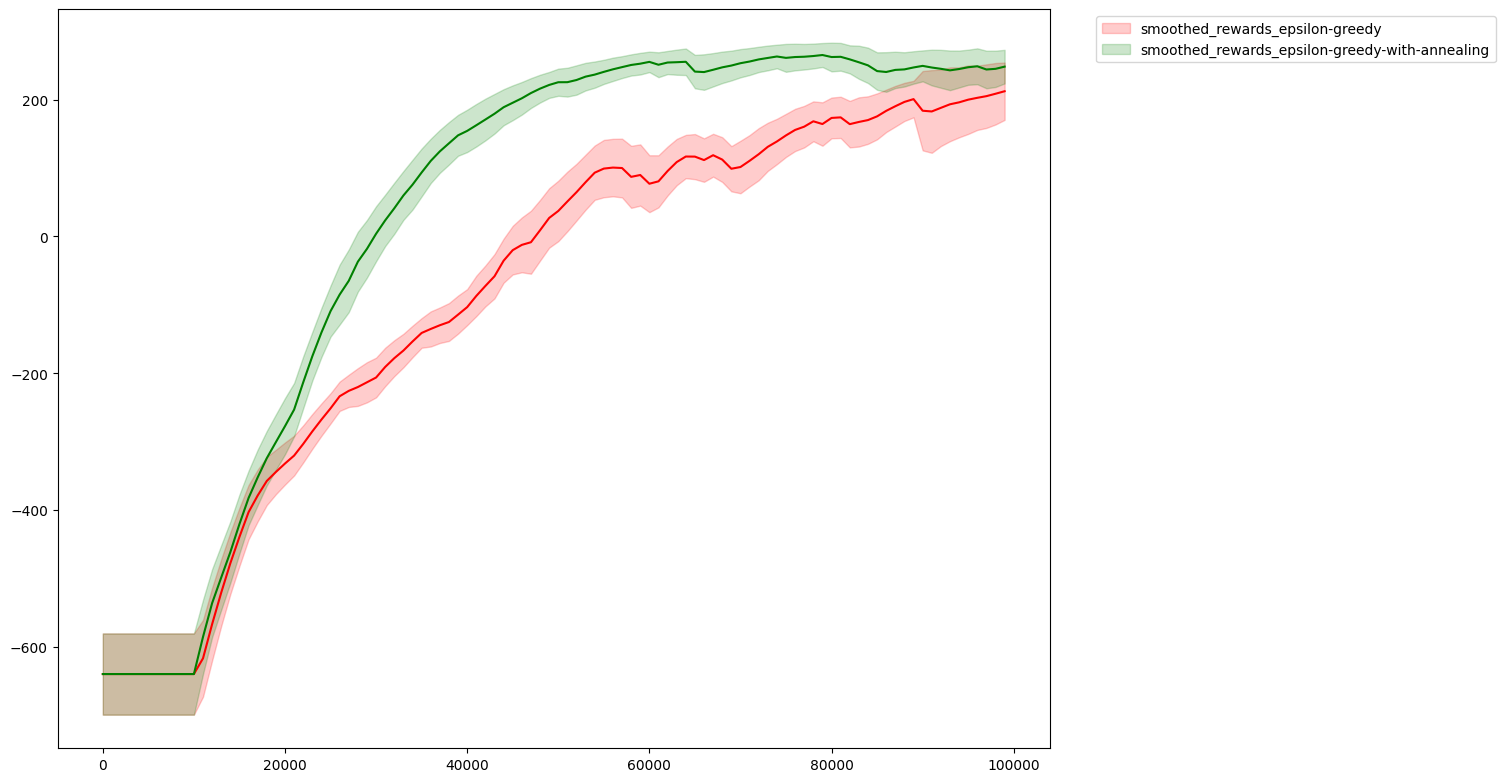

<Figure size 640x480 with 0 Axes>

In [34]:
result_means_list = [
    result_means_epsilon_greedy_dqn,
    result_means_epsilon_greedy_with_annealing_dqn,
]
result_stds_list = [
    result_stds_epsilon_greedy_dqn, 
    result_stds_epsilon_greedy_with_annealing_dqn,
]
names_list = [
    "epsilon-greedy",
    "epsilon-greedy-with-annealing",
]
colours_list = ["red", "green", "blue", "black"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

We can clearly see that epsilon anneling improves out results. We are able to explore more in the early parts of the training and exploit in the later parts.

And if we look only at the boltzmann strategies:

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -587.26053144 -537.3316946  -489.18044116 -439.71945626
 -408.82177503 -381.78563965 -357.77571138 -335.26986321 -304.74277712
 -262.95118896 -225.03610783 -179.7119994  -143.0130688  -107.07435873
  -85.80527708  -60.43996864  -45.48717701  -21.3583756     2.99741197
   28.52437131   45.46180031   63.64824166   81.53702809   97.43895501
  108.43913919  122.35955672  131.23180224  142.67571942  152.11729028
  162.79736985  173.02124399  181.83776394  190.17940895  197.57170308
  204.99673829  211.34085305  216.94200606  221.54244052  223.71795369
  227.5727771   231.38845081  234.82804873  236.56437957  237.80979399
  239.96635609  242.46034978  239.83203848  226.0889903   227.80003616
  228.6223521   230.24359555  230.08897949  228.53896748  229.51706841
  231.75895931  233.29881705  230.60452578  233.00803709  234.93443339
  237.

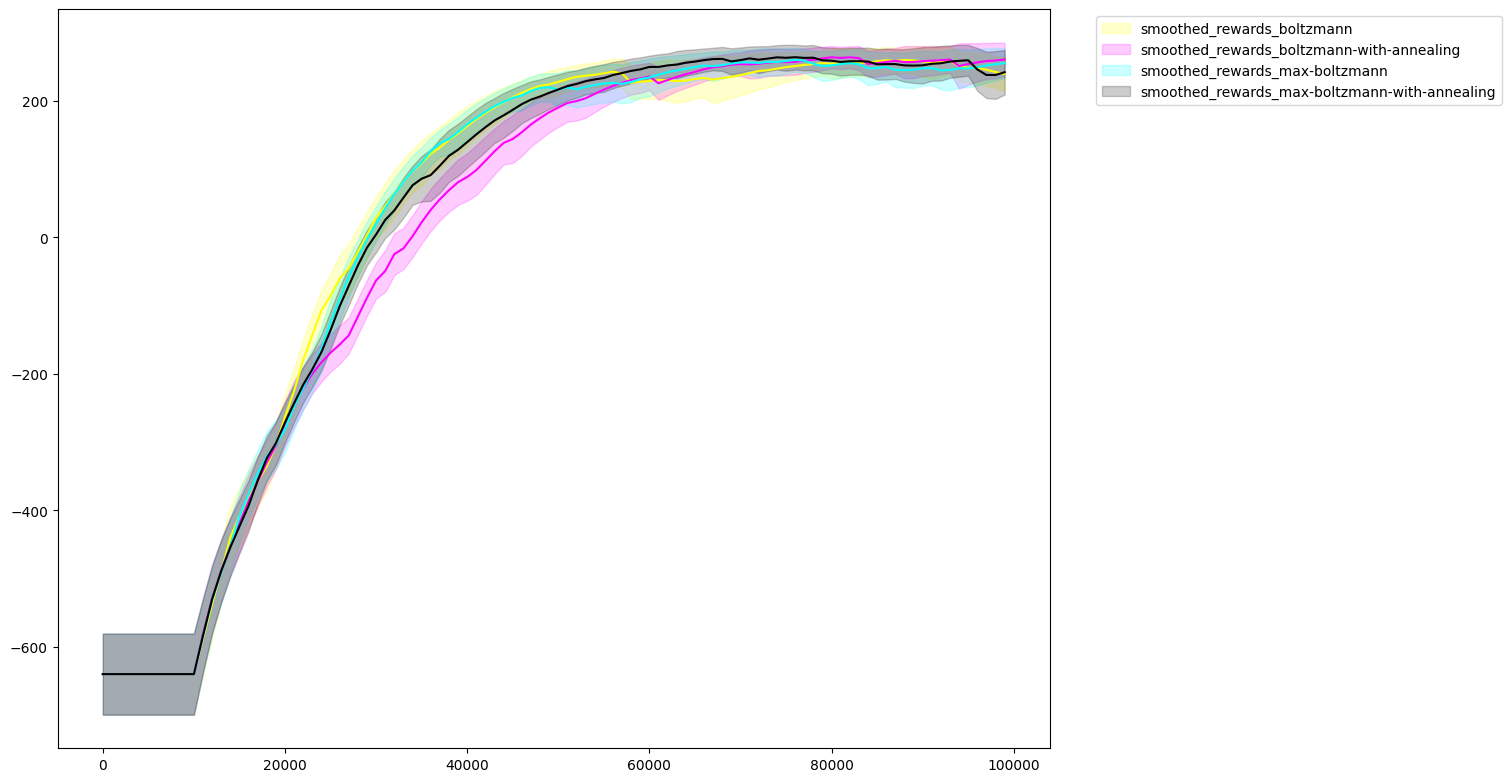

<Figure size 640x480 with 0 Axes>

In [35]:
result_means_list = [
    result_means_boltzmann_dqn, result_means_boltzmann_temp_anneal_dqn,
    result_means_max_boltzmann_dqn, result_means_max_boltzmann_temp_anneal_dqn,
]
result_stds_list = [
    result_stds_boltzmann_dqn, result_stds_boltzmann_temp_anneal_dqn,
    result_stds_max_boltzmann_dqn, result_stds_max_boltzmann_temp_anneal_dqn,
]
names_list = [
    "boltzmann", "boltzmann-with-annealing",
    "max-boltzmann", "max-boltzmann-with-annealing",
]
colours_list = [
    "yellow", "magenta",
    "cyan", "black",
    "orange"
]

plot_results_many(
    result_means_list, 
    result_stds_list,
    names_list, 
    colours_list
)

All trainings performer reasonably well. Oly the Boltzmann with annealing seems to need a bit more time to converge.

Let's also see the max-boltzmann and normal boltzmann strategies separatelly:

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -587.26053144 -537.3316946  -489.18044116 -439.71945626
 -408.82177503 -381.78563965 -357.77571138 -335.26986321 -304.74277712
 -262.95118896 -225.03610783 -179.7119994  -143.0130688  -107.07435873
  -85.80527708  -60.43996864  -45.48717701  -21.3583756     2.99741197
   28.52437131   45.46180031   63.64824166   81.53702809   97.43895501
  108.43913919  122.35955672  131.23180224  142.67571942  152.11729028
  162.79736985  173.02124399  181.83776394  190.17940895  197.57170308
  204.99673829  211.34085305  216.94200606  221.54244052  223.71795369
  227.5727771   231.38845081  234.82804873  236.56437957  237.80979399
  239.96635609  242.46034978  239.83203848  226.0889903   227.80003616
  228.6223521   230.24359555  230.08897949  228.53896748  229.51706841
  231.75895931  233.29881705  230.60452578  233.00803709  234.93443339
  237.

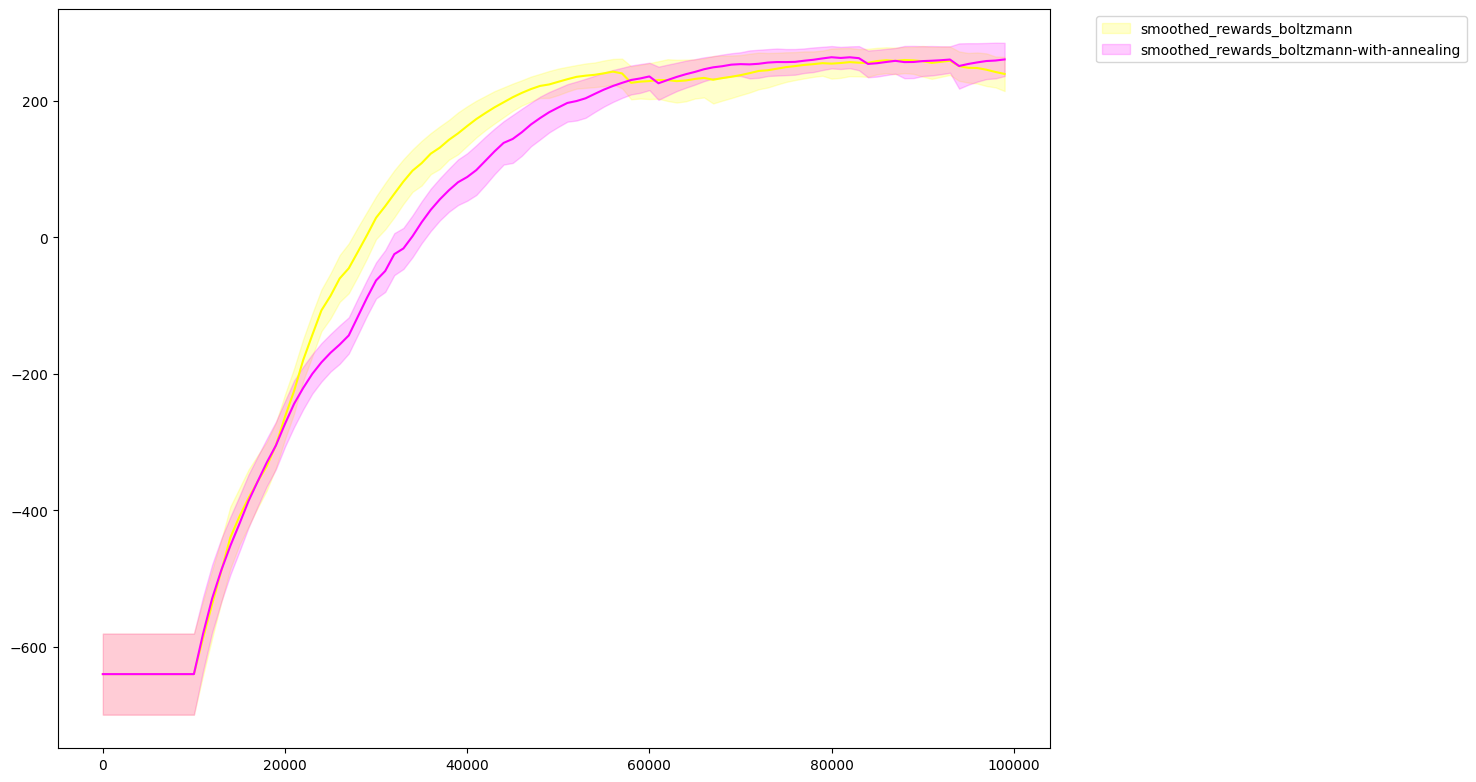

<Figure size 640x480 with 0 Axes>

In [36]:
result_means_list = [
    result_means_boltzmann_dqn, result_means_boltzmann_temp_anneal_dqn,
]
result_stds_list = [
    result_stds_boltzmann_dqn, result_stds_boltzmann_temp_anneal_dqn,
]
names_list = [
    "boltzmann", "boltzmann-with-annealing",
]
colours_list = [
    "yellow", "magenta",
]

plot_results_many(
    result_means_list, 
    result_stds_list,
    names_list, 
    colours_list
)

We can see that annealing slows down the training a bit, but converges to the same value.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -584.30063965 -531.92900004 -490.20592991 -452.2458061
 -408.75432429 -376.32603738 -345.99582261 -321.00514528 -303.18938785
 -281.07163312 -247.63761763 -220.40968192 -194.74093669 -163.77743055
 -124.32625926  -90.4916497   -57.95004367  -29.64213394   -2.80983826
   19.75186203   42.44671968   62.98870786   81.06228308   97.5006483
  109.67151114  125.88833968  137.70493306  143.84732914  154.12577241
  165.36304233  174.81776337  183.7682805   191.77217823  198.17735558
  204.03736171  207.63872034  214.25024029  218.6996993   219.51724832
  215.95075855  219.3585754   216.75255534  220.20870375  222.81881285
  225.12226957  226.10924427  224.65702866  227.30384453  231.59384457
  233.93434156  237.93843943  241.5211252   244.14528586  246.6817059
  249.43666859  251.28830625  250.39489595  251.95677386  254.25358764
  255.945

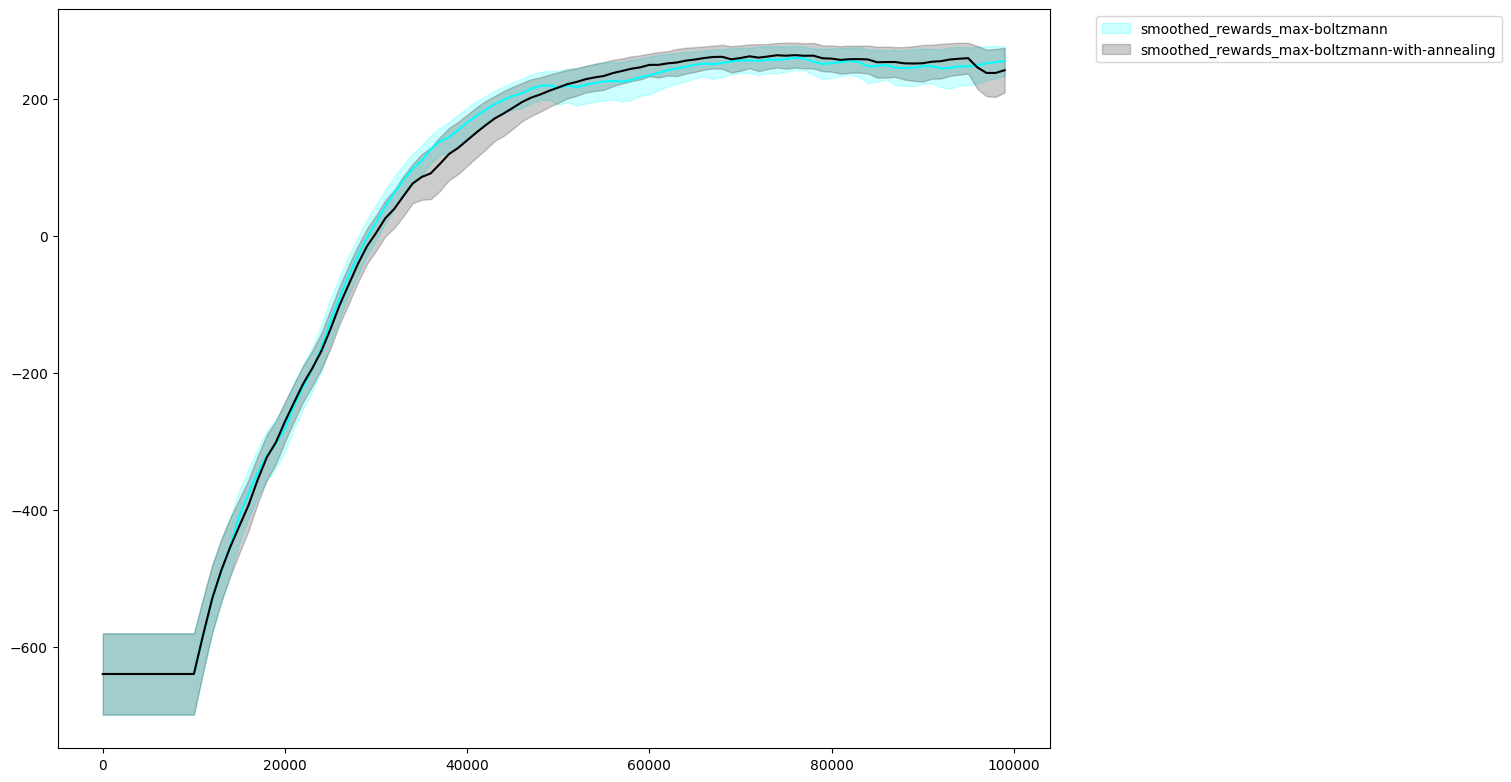

<Figure size 640x480 with 0 Axes>

In [37]:
result_means_list = [
    result_means_max_boltzmann_dqn, result_means_max_boltzmann_temp_anneal_dqn,
]
result_stds_list = [
    result_stds_max_boltzmann_dqn, result_stds_max_boltzmann_temp_anneal_dqn,
]
names_list = [
    "max-boltzmann", "max-boltzmann-with-annealing",
]
colours_list = [
    "cyan", "black",
]

plot_results_many(
    result_means_list, 
    result_stds_list,
    names_list, 
    colours_list
)

Any difference visible on this plot is just noise. Both strategies perform similarly.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -587.26053144 -537.3316946  -489.18044116 -439.71945626
 -408.82177503 -381.78563965 -357.77571138 -335.26986321 -304.74277712
 -262.95118896 -225.03610783 -179.7119994  -143.0130688  -107.07435873
  -85.80527708  -60.43996864  -45.48717701  -21.3583756     2.99741197
   28.52437131   45.46180031   63.64824166   81.53702809   97.43895501
  108.43913919  122.35955672  131.23180224  142.67571942  152.11729028
  162.79736985  173.02124399  181.83776394  190.17940895  197.57170308
  204.99673829  211.34085305  216.94200606  221.54244052  223.71795369
  227.5727771   231.38845081  234.82804873  236.56437957  237.80979399
  239.96635609  242.46034978  239.83203848  226.0889903   227.80003616
  228.6223521   230.24359555  230.08897949  228.53896748  229.51706841
  231.75895931  233.29881705  230.60452578  233.00803709  234.93443339
  237.

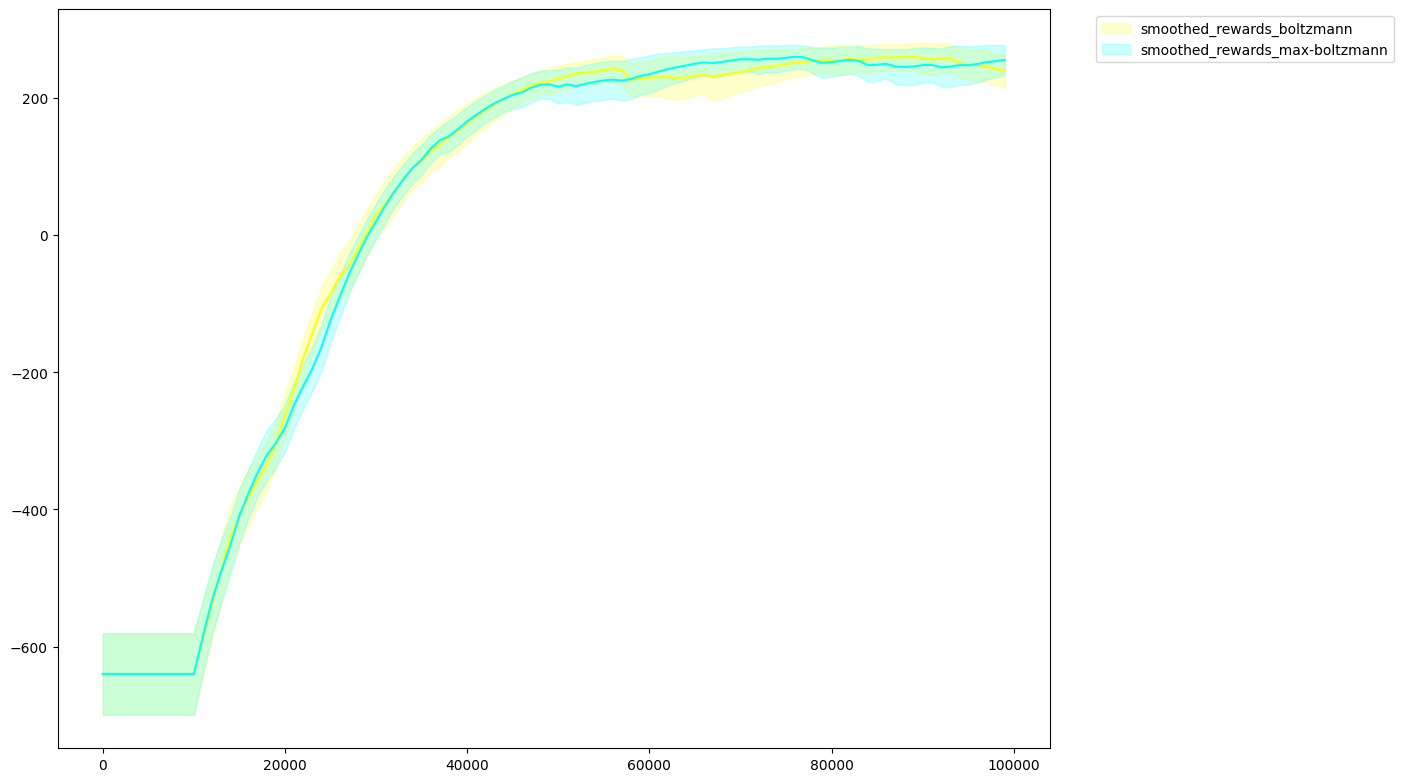

<Figure size 640x480 with 0 Axes>

In [38]:
result_means_list = [
    result_means_boltzmann_dqn,
    result_means_max_boltzmann_dqn,
]
result_stds_list = [
    result_stds_boltzmann_dqn,
    result_stds_max_boltzmann_dqn,
]
names_list = [
    "boltzmann",
    "max-boltzmann",
]
colours_list = [
    "yellow", "cyan",
]

plot_results_many(
    result_means_list, 
    result_stds_list,
    names_list, 
    colours_list
)

We can't really tell if max boltzmann is better than boltzmann. Both strategies perform similarly.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -580.94160066 -529.07221709 -487.79516378 -451.83080919
 -419.4946653  -386.13167299 -357.62543008 -329.80767595 -304.9471131
 -273.2427492  -243.83250158 -220.65353983 -199.98179891 -183.19459335
 -169.12626238 -157.20485868 -143.76952807 -116.19375679  -88.65803975
  -63.21655055  -49.50088027  -24.74801393  -16.41826834    1.45954781
   21.90205179   40.12744548   55.49179561   68.88050675   80.56110613
   88.16264641   98.26373373  111.91406708  125.67030823  138.12787793
  143.90570101  153.72616629  165.10510919  174.45796556  183.04937571
  189.93375678  196.62864458  199.40264327  203.44923223  209.87374696
  216.08655175  221.45755319  226.01664449  230.27228105  232.50395768
  235.44775443  225.43317323  230.18528153  234.71698444  238.6901924
  242.0494236   245.97260588  248.76024465  250.39979196  252.69879405
  253.45

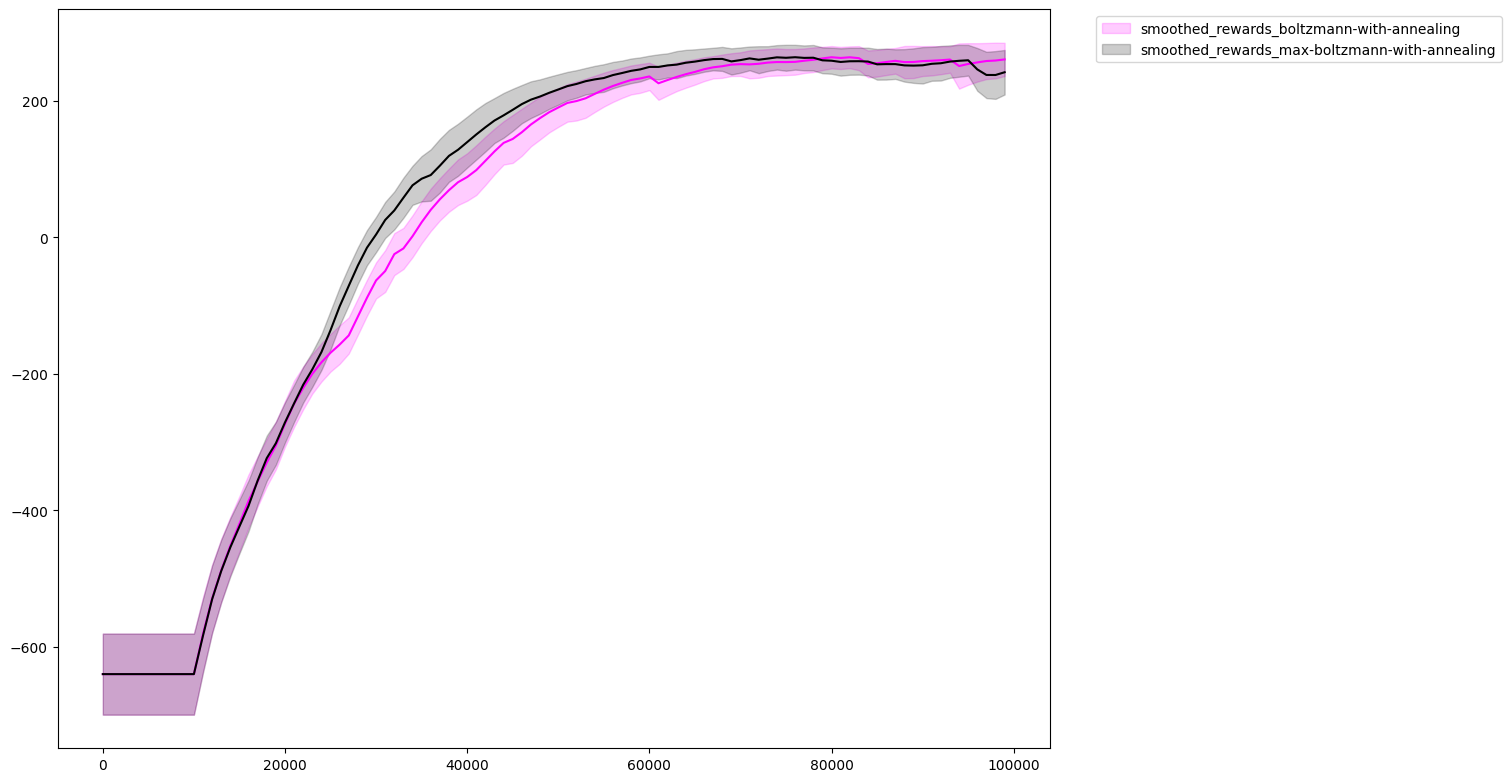

<Figure size 640x480 with 0 Axes>

In [39]:
result_means_list = [
    result_means_boltzmann_temp_anneal_dqn,
    result_means_max_boltzmann_temp_anneal_dqn,
]
result_stds_list = [
    result_stds_boltzmann_temp_anneal_dqn,
    result_stds_max_boltzmann_temp_anneal_dqn,
]
names_list = [
    "boltzmann-with-annealing",
    "max-boltzmann-with-annealing",
]
colours_list = [
    "magenta", "black",
]

plot_results_many(
    result_means_list, 
    result_stds_list,
    names_list, 
    colours_list
)

Max boltzmann learns slightly faster.

### Conclusion

The general image is that Boltzmann strategies generally work better than epsilon greedy. This makes a lot of sense - by sampling from a distribution we have much lower probability of going int nonsense actions and high probability of checking out actions that might have some sense.

However, it's hard to distinguish betweeen the Boltzmann strategies. For all variations I was able to pick hyperparameters in such a way that they converge to ~200 points which means they successfully solve the task. Temperature annealing doesn't seem to help a lot, but epsilon annealing in epsilon-greedy strategy is clearly beneficial.

My presented approaches seem to improve a bit on the ones suggested by homework author, but to check the real benefits they would have to be tested on a little bit less toy-ish problem.